# S&P 500 Hedging Analysis: Volatility Surface and Collar Pricing

**1 April 2025, after the close. A $500M US equity book with a beta of 1. Reciprocal tariffs will be announced
tomorrow at 4pm. Do we hedge, with which structure, and at what cost? And how did that decision play out?**

This notebook answers the question the way an equity derivatives desk would. It rebuilds the S&P 500 implied
volatility surface every trading day from January to June 2025, starting from real SPY option quotes, makes sure it
is free of static arbitrage, checks it against the Cboe VIX, and then uses it to price four hedging structures on
1 April and to mark them every day until they expire on 30 May.

| Module | Output |
|---|---|
| 1. Data | SPY end-of-day option chains (bid/ask), SPY prices, Cboe VIX9D / VIX / VIX3M / VIX6M / SKEW, Treasury yields |
| 2. Cleaning and implied vols | Spot implied by put-call parity, forwards, Black-76 implied vols from bid, mid and ask |
| 3. SVI per expiry | Raw SVI fitted in vol space with no-arbitrage penalties (butterfly, calendar, Lee's bound) |
| 4. Surface across maturities | Interpolation in total variance, sqrt(T) skew rule anchored to VIX9D / VIX3M / VIX6M |
| 5. Calibration | 122 trading days, January to June 2025 |
| 6. Validation | Fit error, out-of-sample VIX, arbitrage audit on 3.4 million grid points |
| 7. Risk metrics | ATM vol, 25-delta risk reversal, put skew, realised vol, implied density |
| 8. The hedging case | Four structures priced at the real quotes, marked daily, hold vs monetise |
| 9. Charts | Surface before and during the crash, VIX check, portfolio paths |
| 10. Export | **Interactive HTML page with the animated 3D surface** |
| 11. Excel | **Hedge pricer with live formulas**, scenarios, daily paths and a hold / sell switch |

> Educational project, not investment advice. All market data are public (DoltHub, Cboe, FRED). The dividend yield,
> the portfolio's beta of 1 and the hedge sizing are assumptions, marked as such.

In [1]:
import subprocess, sys
_ = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scipy", "pandas", "matplotlib", "requests", "openpyxl"], check=False, capture_output=True)

In [2]:
import os, io, json, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import least_squares, brentq

warnings.filterwarnings("ignore")
trapz = getattr(np, "trapezoid", None) or np.trapz
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 0. Configuration

In [3]:
DATA_DIR = "data"                          # bundled CSVs; downloaded from the original sources if missing
START, END = "2025-01-02", "2025-06-30"    # surface window
DECISION = pd.Timestamp("2025-04-01")      # the day the hedge is priced
EXPIRY = pd.Timestamp("2025-05-30")        # listed SPY expiry used for the hedge
NAV0 = 500e6                               # portfolio value, beta 1 to the S&P 500
Q0 = 0.0125                                # SPY dividend yield (assumption)
VIX_TRIGGER = 40.0                         # monetisation rule: sell the hedge at the first close with VIX >= 40

# the four structures: (strike, +1 call / -1 put, +1 buy / -1 sell); strikes must be listed on EXPIRY in the DECISION-day chain
STRUCTURES = {
    "Long put 539":                  [(539, -1, +1)],
    "Put spread 539/475":            [(539, -1, +1), (475, -1, -1)],
    "Collar 539/583":                [(539, -1, +1), (583, +1, -1)],
    "Put-spread collar 539/475/583": [(539, -1, +1), (475, -1, -1), (583, +1, -1)],
}

## 1. Data
* **SPY option chains and prices**: DoltHub `post-no-preference/options` and `post-no-preference/stocks`, public SQL API.
  The dataset holds three expiries a day (about 2, 4 and 8 weeks) and roughly 19 strikes per expiry.
* **Cboe indices**: VIX9D, VIX, VIX3M, VIX6M, VIX1Y, SKEW, VVIX and the S&P 500 index, daily closes.
* **Treasury yields**: FRED constant-maturity series DGS1MO, DGS3MO, DGS6MO, DGS1.

If the `data/` folder is present (it ships with the repository) the notebook reads it; otherwise it downloads
everything from the original sources, which takes a few minutes.

In [4]:
import requests

DOLT = "https://www.dolthub.com/api/v1alpha1/post-no-preference/{db}/master"
CBOE = "https://cdn.cboe.com/api/global/us_indices/daily_prices/{name}_History.csv"
FRED = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS1MO,DGS3MO,DGS6MO,DGS1"

def dolt(db, sql):
    for attempt in range(4):
        try:
            r = requests.get(DOLT.format(db=db), params={"q": sql}, timeout=60)
            j = r.json()
            if "rows" in j:
                return j["rows"]
        except Exception:
            pass
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"DoltHub query failed: {sql}")

def download_all(folder):
    os.makedirs(folder, exist_ok=True)
    days = pd.bdate_range("2024-12-16", END)
    px_rows, opt_rows = [], []
    for d in days:  # one query per day: range queries on the public API are truncated
        ds = d.strftime("%Y-%m-%d")
        p = dolt("stocks", f"SELECT close,open,high,low,volume FROM ohlcv WHERE date='{ds}' AND act_symbol='SPY'")
        if not p:
            continue  # market holiday
        px_rows.append(dict(date=ds, **p[0]))
        o = dolt("options", "SELECT expiration,strike,call_put,bid,ask,vol,delta,gamma,vega FROM option_chain "
                            f"WHERE date='{ds}' AND act_symbol='SPY'")
        for x in o:
            opt_rows.append(dict(date=ds, expiration=x["expiration"], strike=x["strike"], cp=x["call_put"][0], bid=x["bid"],
                                 ask=x["ask"], vendor_iv=x["vol"], delta=x["delta"], gamma=x["gamma"], vega=x["vega"]))
        print(ds, len(o), end=" | ", flush=True)
    pd.DataFrame(px_rows)[["date", "open", "high", "low", "close", "volume"]].to_csv(f"{folder}/spy_ohlcv.csv", index=False)
    pd.DataFrame(opt_rows).to_csv(f"{folder}/spy_options_raw.csv", index=False)
    frames = []
    for name in ["SPX", "VIX9D", "VIX", "VIX3M", "VIX6M", "VIX1Y", "SKEW", "VVIX"]:
        t = pd.read_csv(io.StringIO(requests.get(CBOE.format(name=name), timeout=60).text))
        col = "CLOSE" if "CLOSE" in t.columns else name
        s = pd.Series(t[col].values, index=pd.to_datetime(t["DATE"]), name=name)
        frames.append(s[(s.index >= "2024-12-01") & (s.index <= END)])
    pd.concat(frames, axis=1).dropna(subset=["SPX"]).rename_axis("date").reset_index().to_csv(f"{folder}/cboe_indices.csv", index=False)
    f = pd.read_csv(io.StringIO(requests.get(FRED, timeout=60).text)).rename(columns={"observation_date": "date", "DATE": "date"})
    f = f[(f.date >= "2024-12-01") & (f.date <= END)].replace(".", np.nan).dropna()
    f.to_csv(f"{folder}/fred_treasury.csv", index=False)

if not os.path.exists(f"{DATA_DIR}/spy_options_raw.csv"):
    download_all(DATA_DIR)

opt = pd.read_csv(f"{DATA_DIR}/spy_options_raw.csv", parse_dates=["date", "expiration"])
px = pd.read_csv(f"{DATA_DIR}/spy_ohlcv.csv", parse_dates=["date"]).set_index("date")
cboe = pd.read_csv(f"{DATA_DIR}/cboe_indices.csv", parse_dates=["date"]).set_index("date")
fred = pd.read_csv(f"{DATA_DIR}/fred_treasury.csv", parse_dates=["date"]).set_index("date").astype(float)
opt = opt[opt.date.isin(px.index)].copy()   # drop holiday snapshots (no underlying price that day)
print(f"{len(opt):,} option quotes on {opt.date.nunique()} days; Cboe {cboe.index.min().date()} to {cboe.index.max().date()}")

15,224 option quotes on 133 days; Cboe 2024-12-02 to 2025-06-30


## 2. Cleaning and implied volatilities
**The quotes are not always synchronous with the official close.** On 28 March 2025, for example, put-call parity
implies SPY near 568 while SPY closed at 555.66: the chain was captured intraday. So the underlying level is inferred
from the options themselves, as the median parity-implied spot across the near-the-money strikes of all expiries.

Forwards are `F = S e^((r - q) T)` with `r` from the Treasury curve and `q` = 1.25%. Implied vols come from Black-76 on
the forward, using out-of-the-money options only (puts below the forward, calls above).

In [5]:
def rate(date, T):
    """Continuously compounded rate for maturity T (years), linear on the 1M-3M-6M-1Y CMT curve."""
    row = fred.loc[:date].iloc[-1]
    y = row[["DGS1MO", "DGS3MO", "DGS6MO", "DGS1"]].values / 100
    return float(np.log(1 + np.interp(T, [1 / 12, 0.25, 0.5, 1.0], y)))

def black_norm(k, w, cp):
    """Undiscounted Black price divided by the forward. k = ln(K/F), w = total implied variance, cp = +1 call / -1 put."""
    sw = np.sqrt(np.maximum(w, 1e-16)); d1 = -k / sw + sw / 2; d2 = d1 - sw
    return np.where(cp > 0, norm.cdf(d1) - np.exp(k) * norm.cdf(d2), np.exp(k) * norm.cdf(-d2) - norm.cdf(-d1))

def implied_total_var(price_n, k, cp, lo=1e-8, hi=4.0, it=120):
    """Vectorised bisection on total variance; NaN where the price violates the no-arbitrage bounds."""
    price_n, k, cp = map(np.asarray, (price_n, k, cp))
    intrinsic = np.where(cp > 0, np.maximum(1 - np.exp(k), 0), np.maximum(np.exp(k) - 1, 0))
    upper = np.where(cp > 0, 1.0, np.exp(k))
    ok = (price_n > intrinsic + 1e-12) & (price_n < upper)
    a = np.full(price_n.shape, lo); b = np.full(price_n.shape, hi)
    for _ in range(it):
        m = 0.5 * (a + b); f = black_norm(k, m, cp) - price_n
        a = np.where(f < 0, m, a); b = np.where(f >= 0, m, b)
    return np.where(ok, 0.5 * (a + b), np.nan)

opt["T"] = (opt.expiration - opt.date).dt.days / 365.0
opt["mid"] = (opt.bid + opt.ask) / 2
opt["r"] = [rate(d, T) for d, T in zip(opt.date, opt["T"])]

rows = []
for (d, e), g in opt.groupby(["date", "expiration"]):
    p = g.pivot(index="strike", columns="cp", values="mid").dropna()
    if len(p) < 3: continue
    T, r = g["T"].iloc[0], g["r"].iloc[0]
    near = p.assign(diff=(p["C"] - p["P"]).abs()).nsmallest(4, "diff")
    for f_ in near.index.values + np.exp(r * T) * (near["C"] - near["P"]).values:
        rows.append((d, f_ * np.exp(-(r - Q0) * T)))
spot = pd.DataFrame(rows, columns=["date", "S"]).groupby("date").S.median()

opt["S"] = opt.date.map(spot)
opt["F"] = opt.S * np.exp((opt.r - Q0) * opt["T"])
opt["k"] = np.log(opt.strike / opt.F)
opt["cpn"] = np.where(opt.cp == "C", 1, -1)
disc = np.exp(opt.r * opt["T"])
for c in ["bid", "ask", "mid"]:
    w = implied_total_var(opt[c].values * disc / opt.F.values, opt.k.values, opt.cpn.values)
    opt["iv_" + c] = np.sqrt(w / opt["T"])
otm = ((opt.cp == "C") & (opt.k >= 0)) | ((opt.cp == "P") & (opt.k < 0))
opt["use"] = (otm & (opt.bid >= 0.02) & (opt.ask > opt.bid) & ((opt.ask - opt.bid) / opt.mid <= 0.5)
              & (opt["T"] >= 5 / 365) & opt.iv_mid.notna())
use = opt[opt.use & (opt.date >= START)].copy()
use["wt"] = 1.0 / np.clip(use.iv_ask - use.iv_bid, 0.003, None)   # weight = inverse bid-ask spread in vol

gap = (spot / px.close - 1) * 100
print(f"Quotes used: {len(use):,} ({use.groupby('date').size().mean():.0f} per day)")
print(f"Parity-implied spot vs official close: median {gap.median():+.2f}%, largest {gap.abs().max():.2f}%")
print(f"Implied vol vs the vendor's: median difference {(use.iv_mid - use.vendor_iv).median() * 100:+.2f} vol points")

Quotes used: 6,166 (51 per day)
Parity-implied spot vs official close: median -0.00%, largest 2.14%
Implied vol vs the vendor's: median difference +0.02 vol points


## 3. SVI per expiry
Gatheral's raw SVI, `w(k) = a + b (rho (k - m) + sqrt((k - m)^2 + s^2))`, fitted in implied-vol space with a robust
(soft-L1) loss and weights equal to the inverse bid-ask spread. Penalties enforce:
* **no butterfly arbitrage**: Gatheral's `g(k) >= 0` on `k` in [-1.2, 0.6] (density non-negative);
* **no calendar arbitrage**: the slice never falls below the previous, shorter expiry;
* positive variance and **Lee's moment bound** on the wings, `b (1 + |rho|) <= 2`.

The smile's vertex `m` is kept inside the quoted strike range and `rho <= 0.5`. Without this, sparse slices admit
"phantom" fits whose vertex sits outside the data and whose unobserved wing explodes.

In [6]:
KGRID = np.linspace(-1.2, 0.6, 121)

def svi(k, a, b, rho, m, s):
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + s * s))

def g_fun(k, p):
    a, b, rho, m, s = p
    x = k - m; r = np.sqrt(x * x + s * s)
    w = np.maximum(a + b * (rho * x + r), 1e-12); w1 = b * (rho + x / r); w2 = b * s * s / r ** 3
    return (1 - k * w1 / (2 * w)) ** 2 - w1 * w1 / 4 * (1 / w + 0.25) + w2 / 2

def fit_svi(k, iv, T, wt, prev=None, warm=None):
    wt = wt / wt.mean()
    wprev = svi(KGRID, *prev) if prev is not None else None
    lb = np.array([-0.5, 1e-4, -0.999, k.min(), 1e-3]); ub = np.array([0.5, 2.0, 0.5, k.max(), 1.5])
    def res(p):
        a, b, rho, m, s = p
        r = (np.sqrt(np.maximum(svi(k, *p), 1e-12) / T) - iv) * wt * 100
        pen = [np.sqrt(np.sum(np.minimum(g_fun(KGRID, p) - 2e-3, 0) ** 2)) * 300,
               max(0, -(a + b * s * np.sqrt(1 - rho * rho))) * 1e4,
               max(0, b * (1 + abs(rho)) - 2) * 100]
        if wprev is not None:
            pen.append(np.sqrt(np.sum(np.minimum(svi(KGRID, *p) - wprev, 0) ** 2)) * 1e4)
        return np.concatenate([r, pen])
    wmin = (iv * iv * T).min()
    starts = [] if warm is None else [np.clip(warm, lb + 1e-6, ub - 1e-6)]
    for m0, rho0, s0 in ((-0.02, -0.9, 0.03), (0.03, -0.5, 0.1), (0.08, -0.9, 0.1), (0.03, 0.0, 0.03), (0.08, -0.5, 0.03)):
        starts.append(np.clip([wmin * 0.5, 0.05 + 0.5 * np.sqrt(wmin), rho0, m0, s0], lb + 1e-6, ub - 1e-6))
    best = None
    for x0 in starts:
        r = least_squares(res, x0, bounds=(lb, ub), loss="soft_l1", f_scale=1.0, max_nfev=1500)
        if best is None or r.cost < best.cost: best = r
    return best.x

## 4. The surface across maturities
* **Between listed expiries**: linear in total variance at fixed log-forward moneyness.
* **Outside the listed range** (below about 2 weeks, beyond about 8 weeks): a sqrt(T) skew-scaling rule,
  `w_T(k) = lambda w_ref(k / sqrt(lambda))`, which multiplies the ATM variance by `lambda` and flattens the skew in
  `k` like `1/sqrt(T)`. `lambda` is solved so that the slice's variance-swap vol equals **Cboe VIX9D (9 days),
  VIX3M (93 days) and VIX6M (182 days)**.
* **The 30-day VIX is never used.** It is kept aside as an out-of-sample test of the whole surface.

In [7]:
def varswap_vol(wfun, T, kmin=-3.0, kmax=1.5, n=6001):
    """Continuous-strike variance swap (the VIX formula): VS^2 T = 2 * integral of e^-k OTM(k) dk."""
    k = np.linspace(kmin, kmax, n); w = wfun(k)
    o = black_norm(k, w, np.where(k >= 0, 1, -1))
    return float(np.sqrt(2 * trapz(np.exp(-k) * o, k) / T))

def scaled(wf, lam):
    return lambda k: lam * wf(k / np.sqrt(lam))

ANCHORS = {"VIX9D": 9 / 365, "VIX3M": 93 / 365, "VIX6M": 182 / 365}

class Surface:
    def __init__(self, T, P, anchor_vols=None, anchor_lams=None):
        self.T, self.P = np.asarray(T), list(P)
        wfs = [(lambda p: (lambda k: svi(k, *p)))(p) for p in self.P]
        nodes = list(zip(self.T, wfs)); self.lams = {}
        for name, Ta in ANCHORS.items():
            if self.T[0] <= Ta <= self.T[-1]: continue
            ref = wfs[0] if Ta < self.T[0] else wfs[-1]
            if anchor_lams is not None:
                if name not in anchor_lams: continue
                lam = anchor_lams[name]
            else:
                vol = anchor_vols.get(name, np.nan)
                if np.isnan(vol): continue
                try: lam = brentq(lambda l: varswap_vol(scaled(ref, l), Ta) - vol, 1e-3, 50)
                except ValueError: continue
            nodes.append((Ta, scaled(ref, lam))); self.lams[name] = lam
        nodes.sort(key=lambda x: x[0])
        clean = [nodes[0]]
        for t, wf in nodes[1:]:   # keep ATM total variance increasing (calendar)
            if wf(np.array([0.0]))[0] > clean[-1][1](np.array([0.0]))[0]: clean.append((t, wf))
        self.nodes = clean; self.nT = np.array([t for t, _ in clean])

    def w(self, k, T):
        k = np.asarray(k, float); nT, nd = self.nT, self.nodes
        if T <= nT[0]: return scaled(nd[0][1], T / nT[0])(k)
        if T >= nT[-1]: return scaled(nd[-1][1], T / nT[-1])(k)
        j = np.searchsorted(nT, T) - 1; a = (T - nT[j]) / (nT[j + 1] - nT[j])
        return (1 - a) * nd[j][1](k) + a * nd[j + 1][1](k)

    def iv(self, k, T):
        return np.sqrt(np.maximum(self.w(k, T), 1e-12) / T)

## 5. Calibration, January to June 2025
Each day starts from the previous day's parameters (warm start). About 5 seconds per day, so roughly 10 minutes
for the half-year; results are cached in `calibration.pkl`.

In [8]:
CACHE = "calibration.pkl"
if os.path.exists(CACHE):
    CAL = pickle.load(open(CACHE, "rb"))
    print(f"{len(CAL)} calibrated days loaded from {CACHE} (delete the file to recalibrate)")
else:
    CAL, warm, t0 = {}, None, time.time()
    for d in sorted(pd.to_datetime(use.date.unique())):
        g = use[use.date == d].sort_values("k"); slices, prev = [], None
        for i, (e, h) in enumerate(g.groupby("expiration")):
            if len(h) < 6: continue
            T = h["T"].iloc[0]
            p = fit_svi(h.k.values, h.iv_mid.values, T, h.wt.values, prev, warm[i] if warm and i < len(warm) else None)
            slices.append((T, p)); prev = p
        row = cboe.loc[d]
        S = Surface([t for t, _ in slices], [p for _, p in slices], anchor_vols={n: row[n] / 100 for n in ANCHORS})
        warm = S.P
        ivm = np.array([S.iv(k, T) for k, T in zip(g.k.values, g["T"].values)])
        CAL[d] = dict(T=S.T, P=S.P, lams=S.lams, rmse=float(np.sqrt(np.mean((ivm - g.iv_mid.values) ** 2)) * 100),
                      nq=len(g), vix_model=varswap_vol(lambda k: S.w(k, 30 / 365), 30 / 365) * 100)
        print(pd.Timestamp(d).date(), f"{CAL[d]['rmse']:.2f}", end=" | ", flush=True)
    pickle.dump(CAL, open(CACHE, "wb"))
    print(f"\n{len(CAL)} days in {time.time() - t0:.0f}s")

SURF = {d: Surface(e["T"], e["P"], anchor_lams=e["lams"]) for d, e in CAL.items()}
DATES = sorted(SURF)

122 calibrated days loaded from calibration.pkl (delete the file to recalibrate)


## 6. Validation
Three checks: how well the surface fits the quotes, whether it reproduces the VIX it never saw, and whether it is
free of static arbitrage everywhere, not only on the fitted slices.

In [9]:
val = pd.DataFrame({d: dict(rmse=e["rmse"], vix_model=e["vix_model"], vix=cboe.VIX[d]) for d, e in CAL.items()}).T
val["err"] = val.vix_model - val.vix
print(f"Fit error (RMSE, vol points): mean {val.rmse.mean():.2f}, median {val.rmse.median():.2f}, max {val.rmse.max():.2f}")
print(f"VIX out of sample: mean error {val.err.mean():+.2f}, median {val.err.median():+.2f}, "
      f"std {val.err.std():.2f}, correlation {np.corrcoef(val.vix_model, val.vix)[0, 1]:.4f}")
print("Largest VIX gaps:\n", val.reindex(val.err.abs().sort_values(ascending=False).index).head(4)[["vix", "vix_model", "err"]])

# static-arbitrage audit on the full interpolated surface
K = np.linspace(-0.5, 0.3, 161); TT = np.arange(7, 183) / 365; h = K[1] - K[0]
n_cal = v_cal = n_bf = v_bf = 0; worst_cal = 0.0
for d in DATES:
    W = np.array([SURF[d].w(K, T) for T in TT])
    dW = np.diff(W, axis=0); n_cal += dW.size; v_cal += (dW < -1e-10).sum(); worst_cal = min(worst_cal, dW.min())
    w1 = np.gradient(W, h, axis=1); w2 = np.gradient(w1, h, axis=1)
    g = ((1 - K * w1 / (2 * W)) ** 2 - w1 ** 2 / 4 * (1 / W + 0.25) + w2 / 2)[:, 2:-2]
    n_bf += g.size; v_bf += (g < -1e-6).sum()
print(f"Butterfly: {v_bf} violations out of {n_bf:,} grid points")
print(f"Calendar: {v_cal} violations out of {n_cal:,} ({v_cal / n_cal:.3%}), largest breach {worst_cal:.1e} in total variance")

Fit error (RMSE, vol points): mean 0.47, median 0.41, max 1.16
VIX out of sample: mean error -0.15, median -0.12, std 0.63, correlation 0.9957
Largest VIX gaps:
              vix  vix_model   err
2025-04-08 52.33      49.42 -2.91
2025-03-24 17.48      19.66  2.18
2025-03-28 21.65      19.97 -1.68
2025-03-03 22.78      21.12 -1.66


Butterfly: 0 violations out of 3,371,104 grid points
Calendar: 523 violations out of 3,437,350 (0.015%), largest breach -3.8e-05 in total variance


## 7. Risk metrics from the surface
For every day: 30-day ATM vol, the 25-delta risk reversal (call minus put vol), the 90% put skew (90% strike minus
ATM), 21-day realised volatility of the S&P 500 and the 30-day risk-neutral density (Breeden-Litzenberger).

In [10]:
def k_at_delta(S, T, delta, call):
    def f(k):
        w = S.w(np.array([k]), T)[0]; d1 = (-k + w / 2) / np.sqrt(w)
        return (norm.cdf(d1) if call else norm.cdf(-d1)) - delta
    return brentq(f, -1.5, 1.0)

rv21 = np.log(cboe.SPX).diff().rolling(21).std() * np.sqrt(252) * 100
T30 = 30 / 365
met = []
for d in DATES:
    S = SURF[d]; s0 = spot[d]; F30 = s0 * np.exp((rate(d, T30) - Q0) * T30)
    atm = S.iv(np.array([0.0]), T30)[0]
    put25 = S.iv(np.array([k_at_delta(S, T30, 0.25, False)]), T30)[0]
    call25 = S.iv(np.array([k_at_delta(S, T30, 0.25, True)]), T30)[0]
    iv90 = S.iv(np.array([np.log(0.9 * s0 / F30)]), T30)[0]
    met.append(dict(date=d, spy=s0, vix=cboe.VIX[d], vix_rebuilt=CAL[d]["vix_model"], atm30=atm * 100, rv21=rv21[d],
                    rr25=(call25 - put25) * 100, skew90=(iv90 - atm) * 100, vix9d=cboe.VIX9D[d], vix3m=cboe.VIX3M[d]))
met = pd.DataFrame(met).set_index("date")
met.loc[pd.to_datetime(["2025-02-19", "2025-03-31", "2025-04-01", "2025-04-04", "2025-04-08", "2025-04-09", "2025-05-12", "2025-06-30"])]

,spy,vix,vix_rebuilt,atm30,rv21,rr25,skew90,vix9d,vix3m
2025-02-19,611.97,15.27,15.20,11.70,10.63,-3.44,11.32,13.06,17.93
2025-03-31,556.42,22.28,21.80,18.76,20.68,-4.92,8.76,25.14,21.97
2025-04-01,561.36,21.77,21.05,17.68,20.05,-4.96,9.51,24.46,21.82
2025-04-04,505.66,45.31,43.81,36.82,32.23,-14.18,11.16,57.17,36.71
2025-04-08,498.29,52.33,49.42,41.86,31.27,-17.59,11.67,67.63,41.50
2025-04-09,545.87,33.62,34.82,25.55,45.77,-9.41,11.89,40.06,29.92
2025-05-12,582.81,18.39,18.06,15.14,21.80,-3.65,9.54,17.97,20.22
2025-06-30,618.18,16.73,16.45,13.59,9.70,-3.44,9.87,13.77,19.44


## 8. The hedging case
**Sizing**: contracts = NAV / (SPY x 100), so the hedges cover the whole book. **Entry** at the real 1 April quotes
on the 30 May expiry: pay the ask on longs, receive the bid on shorts. **Daily marks** on that day's fitted surface.
**Two management rules**: hold to expiry, or sell everything at the first close with VIX >= 40 (model mid minus half
the quoted spread on each leg).

In [11]:
def model_mid(d, K, cp):
    T = (EXPIRY - d).days / 365; S = spot[d]
    if T <= 0: return max(0.0, (S - K) if cp > 0 else (K - S))
    r = rate(d, T); F = S * np.exp((r - Q0) * T); k = np.log(K / F)
    w = SURF[d].w(np.array([k]), T)[0]
    return float(np.exp(-r * T) * F * black_norm(np.array([k]), np.array([w]), np.array([cp]))[0])

def quote(d, K, cp):
    q = opt[(opt.date == d) & (opt.expiration == EXPIRY) & (opt.strike == K) & (opt.cp == ("C" if cp > 0 else "P"))]
    return None if q.empty else q.iloc[0]

def half_spread(d, K, cp):
    q = quote(d, K, cp)
    if q is not None: return float((q.ask - q.bid) / 2)
    g = opt[(opt.date == d) & (opt.expiration == EXPIRY) & (opt.cp == ("C" if cp > 0 else "P"))]
    return float(((g.ask - g.bid) / 2).iloc[(g.strike - K).abs().argsort()[:3]].median()) if len(g) else 0.02

days = [d for d in DATES if DECISION <= d <= EXPIRY]
S0 = spot[DECISION]; N = NAV0 / (S0 * 100)
trigger = next(d for d in days if cboe.VIX[d] >= VIX_TRIGGER)
trough = min(days, key=lambda d: spot[d])
paths = pd.DataFrame(index=days); paths["Unhedged"] = [NAV0 * spot[d] / S0 for d in days]

def max_dd(s):
    s = np.asarray(s); peak = np.maximum.accumulate(np.r_[NAV0, s])[1:]
    return float(((s - peak) / peak).min() * 100)

res = {}
for name, legs in STRUCTURES.items():
    cost = sum(n * (quote(DECISION, K, cp).ask if n > 0 else quote(DECISION, K, cp).bid) for K, cp, n in legs)
    val_ = pd.Series({d: sum(n * model_mid(d, K, cp) for K, cp, n in legs) for d in days})
    exit_val = sum(n * model_mid(trigger, K, cp) - abs(n) * half_spread(trigger, K, cp) for K, cp, n in legs)
    hold = paths["Unhedged"] + N * 100 * (val_ - cost)
    mon = paths["Unhedged"] + N * 100 * (val_.where(val_.index < trigger, exit_val) - cost)
    paths[name] = hold; paths[name + " | monetised"] = mon
    res[name] = {"Premium / share": cost, "Model mid": sum(n * model_mid(DECISION, K, cp) for K, cp, n in legs),
                 "Cost ($M)": N * 100 * cost / 1e6, "Cost (% NAV)": N * 100 * cost / NAV0 * 100,
                 "NAV at trough ($M)": hold[trough] / 1e6, "Max DD, hold (%)": max_dd(hold),
                 "NAV 30 May, hold ($M)": hold.iloc[-1] / 1e6, "Sold on trigger for ($M)": N * 100 * exit_val / 1e6,
                 "Max DD, monetised (%)": max_dd(mon), "NAV 30 May, monetised ($M)": mon.iloc[-1] / 1e6}
results = pd.DataFrame(res).T
results.loc["Unhedged"] = pd.Series({"NAV at trough ($M)": paths.Unhedged[trough] / 1e6, "Max DD, hold (%)": max_dd(paths.Unhedged),
                           "NAV 30 May, hold ($M)": paths.Unhedged.iloc[-1] / 1e6, "NAV 30 May, monetised ($M)": paths.Unhedged.iloc[-1] / 1e6})
print(f"1 April: SPY {S0:.2f}, {N:,.0f} contracts. Trough on {trough.date()} (SPY {spot[trough]:.2f} at the quote snapshot). "
      f"VIX trigger on {trigger.date()} (VIX {cboe.VIX[trigger]:.2f}).")
r0 = met.loc[DECISION]
print(f"On the decision day: 30d ATM {r0.atm30:.1f}% vs 21d realised {r0.rv21:.1f}%; 25d RR {r0.rr25:+.2f} "
      f"(half-year median {met.rr25.median():+.2f}); VIX9D {r0.vix9d:.1f} vs VIX {r0.vix:.1f}")

# marking check: model vs quoted mid on the days the exact strikes were listed
chk = []
for d in days:
    for K_, cp in {(K, cp) for legs in STRUCTURES.values() for K, cp, _ in legs}:
        q = quote(d, K_, cp)
        if q is not None and d < EXPIRY: chk.append(model_mid(d, K_, cp) - (q.bid + q.ask) / 2)
print(f"Marking check: {len(chk)} comparisons, mean absolute gap ${np.mean(np.abs(chk)):.2f}")
results.round(2)

1 April: SPY 561.36, 8,907 contracts. Trough on 2025-04-08 (SPY 498.29 at the quote snapshot). VIX trigger on 2025-04-04 (VIX 45.31).
On the decision day: 30d ATM 17.7% vs 21d realised 20.1%; 25d RR -4.96 (half-year median -4.51); VIX9D 24.5 vs VIX 21.8


Marking check: 12 comparisons, mean absolute gap $0.13


,Premium / share,Model mid,Cost ($M),Cost (% NAV),NAV at trough ($M),"Max DD, hold (%)","NAV 30 May, hold ($M)",Sold on trigger for ($M),"Max DD, monetised (%)","NAV 30 May, monetised ($M)"
Long put 539,8.36,8.08,7.45,1.49,478.64,-4.62,516.91,36.06,-5.84,552.97
Put spread 539/475,6.59,6.21,5.87,1.17,463.41,-7.66,518.49,22.64,-8.22,541.12
Collar 539/583,1.40,1.26,1.25,0.25,483.83,-3.41,518.03,34.48,-5.43,557.59
Put-spread collar 539/475/583,-0.37,-0.61,-0.33,-0.07,468.60,-6.47,519.61,21.05,-7.15,545.74
Unhedged,NaN,NaN,NaN,NaN,443.83,-11.76,524.36,NaN,NaN,524.36


## 9. Charts

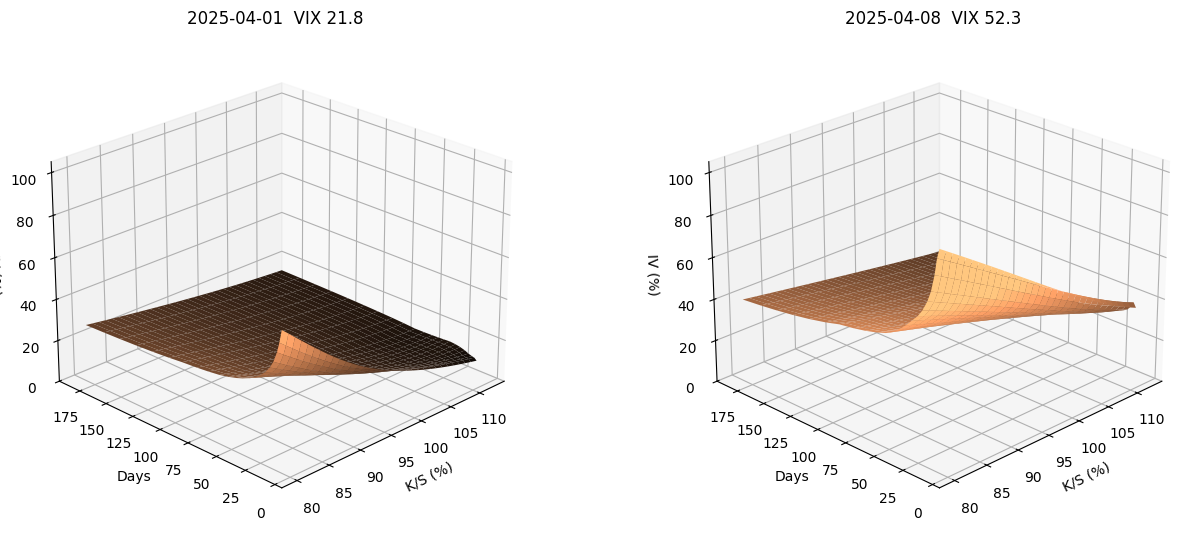

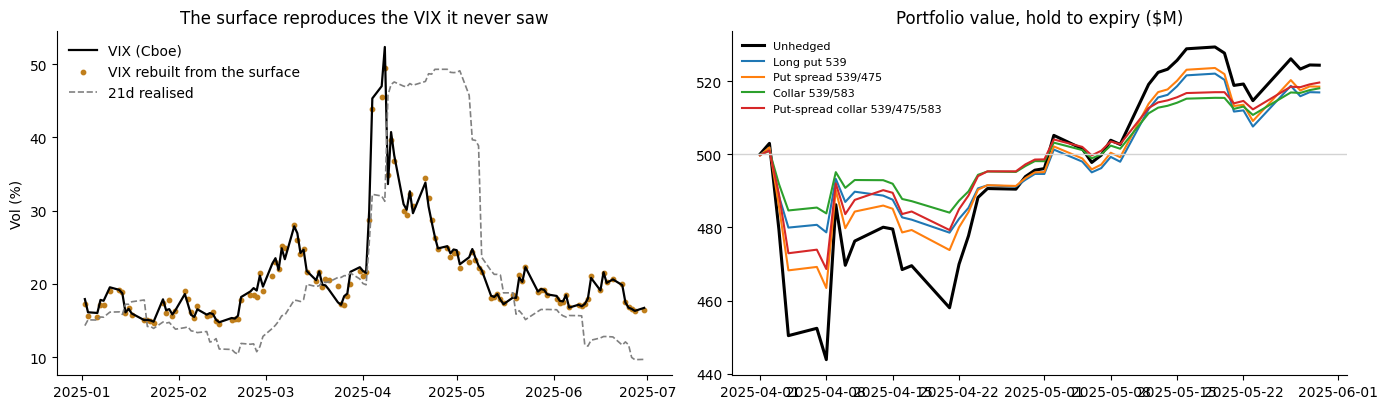

In [12]:
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.spines.top": False, "axes.spines.right": False})
Mg = np.arange(80, 113, 1.0); Tg = np.array([7, 9, 11, 14, 17, 21, 25, 30, 35, 40, 45, 52, 60, 70, 80, 93, 105, 120, 135, 150, 165, 182.0])

def grid(d):
    s0 = spot[d]
    return np.array([SURF[d].iv(np.log(Mg / 100 * s0 / (s0 * np.exp((rate(d, t / 365) - Q0) * t / 365))), t / 365) * 100 for t in Tg])

fig = plt.figure(figsize=(14, 5.5))
for i, d in enumerate([DECISION, pd.Timestamp("2025-04-08")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    X, Y = np.meshgrid(Mg, Tg)
    ax.plot_surface(X, Y, np.minimum(grid(d), 105), cmap="copper", vmin=8, vmax=70, linewidth=0, antialiased=True)
    ax.set(xlabel="K/S (%)", ylabel="Days", zlabel="IV (%)", zlim=(0, 105), title=f"{d.date()}  VIX {cboe.VIX[d]:.1f}")
    ax.view_init(elev=24, azim=225)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].plot(met.index, met.vix, color="black", lw=1.6, label="VIX (Cboe)")
ax[0].scatter(met.index, met.vix_rebuilt, s=10, color="#c07f1c", label="VIX rebuilt from the surface")
ax[0].plot(met.index, met.rv21, color="grey", lw=1.2, ls="--", label="21d realised")
ax[0].set(title="The surface reproduces the VIX it never saw", ylabel="Vol (%)"); ax[0].legend(frameon=False)
for c in ["Unhedged"] + list(STRUCTURES):
    ax[1].plot(paths.index, paths[c] / 1e6, lw=2.2 if c == "Unhedged" else 1.5, color="black" if c == "Unhedged" else None, label=c)
ax[1].axhline(500, color="lightgrey", lw=1); ax[1].set(title="Portfolio value, hold to expiry ($M)"); ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

The page template (HTML, CSS and JavaScript) is kept in the notebook so the project runs from a single file.
The page loads Plotly and the fonts from public CDNs.

In [13]:
PAGE_TEMPLATE = r'''<meta charset="utf-8">
<title>S&amp;P 500 Hedging Analysis</title>
<meta name="author" content="Alessandro Radice">
<meta name="description" content="An arbitrage-free S&amp;P 500 implied volatility surface rebuilt daily from real SPY option quotes (January to June 2025), used to price and evaluate a hedge ahead of the April 2025 tariff shock.">
<link rel="preconnect" href="https://fonts.googleapis.com">
<link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
<link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=Instrument+Serif:ital@0;1&family=IBM+Plex+Sans:wght@400;500;600&family=IBM+Plex+Mono:wght@400;500&display=swap">
<script src="https://cdn.jsdelivr.net/npm/plotly.js-dist-min@2.35.2/plotly.min.js"></script>
<style>
  /* A deliberate single dark look: a trading-desk screen at night. Every colour is painted explicitly. */
  :root {
    color-scheme: dark;
    --ground: #0f1216;
    --panel: #151a20;
    --panel-2: #1a2028;
    --rule: #28303a;
    --rule-strong: #3a4450;
    --text: #ece9e2;
    --text-2: #b9b6ae;
    --muted: #8a929d;
    --amber: #f0b247;
    --amber-deep: #c07f1c;
    --s1: #3987e5; --s2: #d95926; --s3: #199e70; --s4: #c98500;
    --neutral-line: #d9d5cc;
    --good: #3fb37f; --bad: #e66767;
    --serif: "Instrument Serif", "Iowan Old Style", "Palatino Linotype", Georgia, serif;
    --sans: "IBM Plex Sans", -apple-system, "Segoe UI", Roboto, sans-serif;
    --mono: "IBM Plex Mono", ui-monospace, "SFMono-Regular", Menlo, Consolas, monospace;
  }
  * { box-sizing: border-box; }
  html { background: var(--ground); }
  body { background: var(--ground); color: var(--text); font-family: var(--sans); font-size: 15px; line-height: 1.55; margin: 0; }
  .wrap { max-width: 1280px; margin: 0 auto; padding-inline: 24px; padding-block: 32px 64px; }
  @media (max-width: 640px) { .wrap { padding-inline: 16px; padding-block: 20px 48px; } }

  /* ---------- masthead ---------- */
  .eyebrow { font-family: var(--mono); font-size: 12px; letter-spacing: .08em; text-transform: uppercase; color: var(--muted); }
  h1 { font-family: var(--serif); font-weight: 400; font-size: clamp(40px, 6vw, 72px); line-height: 1.02; margin: 10px 0 14px; text-wrap: balance; letter-spacing: -.01em; }
  h1 em { color: var(--amber); font-style: italic; }
  .h1sub { display: block; font-size: 0.56em; line-height: 1.15; margin-top: 6px; color: var(--text-2); }
  .dek { font-size: 17px; color: var(--text-2); max-width: 68ch; margin: 0; }
  .masthead { display: grid; grid-template-columns: minmax(0, 1.35fr) minmax(0, 1fr); gap: 40px; align-items: end; padding-bottom: 28px; border-bottom: 1px solid var(--rule); }
  .brief { border-left: 2px solid var(--amber); padding: 4px 0 4px 18px; }
  .brief .label { font-family: var(--mono); font-size: 11px; letter-spacing: .1em; text-transform: uppercase; color: var(--amber); margin-bottom: 6px; }
  .brief p { margin: 0; font-family: var(--serif); font-size: 22px; line-height: 1.3; color: var(--text); }
  @media (max-width: 900px) { .masthead { grid-template-columns: 1fr; gap: 20px; } }

  /* ---------- findings strip ---------- */
  .findings { display: grid; grid-template-columns: repeat(4, minmax(0, 1fr)); border-bottom: 1px solid var(--rule); }
  .finding { padding: 18px 20px 18px 0; }
  .finding + .finding { padding-left: 20px; border-left: 1px solid var(--rule); }
  .finding .v { font-family: var(--mono); font-size: 26px; font-weight: 500; font-variant-numeric: tabular-nums; color: var(--text); white-space: nowrap; }
  @media (max-width: 640px) { .finding .v { font-size: 17px; } .finding { padding-right: 10px; } .finding + .finding { padding-left: 10px; } }
  .finding .k { font-size: 13px; color: var(--muted); margin-top: 2px; }
  @media (max-width: 900px) { .findings { grid-template-columns: repeat(2, minmax(0, 1fr)); } .finding:nth-child(3) { border-left: 0; padding-left: 0; } .finding:nth-child(n+3) { border-top: 1px solid var(--rule); } }

  /* ---------- control bar ---------- */
  .controls { position: sticky; top: env(safe-area-inset-top, 0px); z-index: 20; background: rgba(15, 18, 22, .94); backdrop-filter: blur(6px); border-bottom: 1px solid var(--rule); padding: 12px 0 10px; margin-top: 8px; }
  .ctrl-row { display: flex; align-items: center; gap: 14px; flex-wrap: wrap; }
  .date { font-family: var(--mono); font-size: 20px; font-weight: 500; min-width: 15ch; font-variant-numeric: tabular-nums; }
  .btn { font: 500 13px var(--sans); color: var(--text); background: var(--panel-2); border: 1px solid var(--rule-strong); border-radius: 6px; padding: 7px 12px; cursor: pointer; }
  .btn:hover { border-color: var(--muted); }
  .btn:focus-visible, .chip:focus-visible, input[type=range]:focus-visible, .seg button:focus-visible { outline: 2px solid var(--amber); outline-offset: 2px; }
  .btn[aria-pressed="true"] { background: var(--amber); color: #1a1406; border-color: var(--amber); }
  input[type=range] { flex: 1 1 260px; accent-color: var(--amber); min-width: 0; }
  .chips { display: flex; gap: 6px; overflow-x: auto; padding: 10px 0 2px; scrollbar-width: thin; }
  .chip { flex: 0 0 auto; font: 12px var(--mono); color: var(--text-2); background: transparent; border: 1px solid var(--rule-strong); border-radius: 999px; padding: 4px 10px; cursor: pointer; white-space: nowrap; }
  .chip:hover { color: var(--text); border-color: var(--muted); }
  .chip.on { color: #1a1406; background: var(--amber); border-color: var(--amber); }
  .event { font-size: 14px; color: var(--text-2); min-height: 22px; margin-top: 6px; }
  .event b { color: var(--amber); font-weight: 500; }

  /* ---------- panels ---------- */
  section { margin-top: 36px; }
  h2 { font-family: var(--serif); font-weight: 400; font-size: clamp(28px, 3.6vw, 40px); line-height: 1.1; margin: 0 0 8px; text-wrap: balance; }
  h3 { font: 600 13px var(--sans); letter-spacing: .06em; text-transform: uppercase; color: var(--text-2); margin: 0 0 2px; }
  .sub { font-size: 13px; color: var(--muted); margin: 0 0 8px; }
  .lead { color: var(--text-2); max-width: 70ch; margin: 0 0 18px; }
  .panel { background: var(--panel); border: 1px solid var(--rule); border-radius: 10px; padding: 16px 16px 8px; min-width: 0; }
  .hero { display: grid; grid-template-columns: minmax(0, 1fr) 290px; gap: 16px; margin-top: 20px; }
  @media (max-width: 1000px) { .hero { grid-template-columns: 1fr; } }
  #surface { height: 640px; }
  @media (max-width: 640px) { #surface { height: 440px; } }
  .grid3 { display: grid; grid-template-columns: repeat(3, minmax(0, 1fr)); gap: 16px; margin-top: 16px; }
  .grid2 { display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap: 16px; margin-top: 16px; }
  @media (max-width: 1000px) { .grid3, .grid2 { grid-template-columns: 1fr; } }
  .chart { height: 300px; }

  /* readout */
  .readout { display: flex; flex-direction: column; gap: 0; padding: 16px 18px; }
  .ro { display: grid; grid-template-columns: 1fr auto; gap: 2px 12px; padding: 10px 0; border-bottom: 1px solid var(--rule); align-items: baseline; }
  .ro:last-child { border-bottom: 0; }
  .ro .n { font-size: 13px; color: var(--text-2); }
  .ro .x { font-family: var(--mono); font-size: 18px; font-variant-numeric: tabular-nums; text-align: right; }
  .ro .d { grid-column: 1 / -1; font-size: 12px; color: var(--muted); }
  .pill { display: inline-block; font: 500 11px var(--mono); letter-spacing: .05em; text-transform: uppercase; padding: 2px 8px; border-radius: 999px; border: 1px solid currentColor; }
  .pill.inv { color: var(--bad); }
  .pill.con { color: var(--good); }

  /* ---------- tables ---------- */
  .tablewrap { overflow-x: auto; margin-top: 12px; }
  table { border-collapse: collapse; width: 100%; font-size: 14px; }
  th, td { padding: 10px 12px; text-align: right; border-bottom: 1px solid var(--rule); white-space: nowrap; font-variant-numeric: tabular-nums; }
  th { font: 500 12px var(--sans); color: var(--muted); letter-spacing: .03em; border-bottom-color: var(--rule-strong); vertical-align: bottom; }
  td { font-family: var(--mono); font-size: 13.5px; }
  th:first-child, td:first-child { text-align: left; font-family: var(--sans); }
  td .key { display: inline-block; width: 14px; height: 2px; vertical-align: middle; margin-right: 8px; border-radius: 1px; }
  tr.best td { background: rgba(240, 178, 71, .07); }
  .neg { color: var(--bad); } .pos { color: var(--good); }
  .seg { display: inline-flex; border: 1px solid var(--rule-strong); border-radius: 8px; overflow: hidden; }
  .seg button { font: 500 13px var(--sans); background: transparent; color: var(--text-2); border: 0; padding: 7px 14px; cursor: pointer; }
  .seg button[aria-pressed="true"] { background: var(--panel-2); color: var(--text); box-shadow: inset 0 -2px 0 var(--amber); }
  .casehead { display: flex; justify-content: space-between; align-items: end; gap: 16px; flex-wrap: wrap; }
  #nav { height: 380px; }

  .verdict { display: grid; grid-template-columns: minmax(0, 1fr) minmax(0, 1fr); gap: 32px; margin-top: 20px; }
  .verdict p { margin: 0 0 12px; color: var(--text-2); }
  .verdict p strong { color: var(--text); font-weight: 600; }
  .verdict .call { font-family: var(--serif); font-size: 26px; line-height: 1.25; color: var(--text); margin: 0 0 12px; }
  @media (max-width: 900px) { .verdict { grid-template-columns: 1fr; gap: 8px; } }

  .method { display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap: 12px 40px; counter-reset: step; margin: 16px 0 0; padding: 0; list-style: none; }
  .method li { counter-increment: step; position: relative; padding-left: 36px; color: var(--text-2); font-size: 14px; }
  .method li::before { content: counter(step, decimal-leading-zero); position: absolute; left: 0; top: 1px; font: 12px var(--mono); color: var(--amber); }
  .method li b { color: var(--text); font-weight: 600; }
  @media (max-width: 900px) { .method { grid-template-columns: 1fr; } }
  .notes { color: var(--muted); font-size: 13.5px; max-width: 90ch; }
  .notes li { margin-bottom: 6px; }
  .sources { columns: 2; column-gap: 40px; font-size: 13px; color: var(--muted); padding-left: 18px; }
  .sources li { margin-bottom: 6px; break-inside: avoid; }
  @media (max-width: 800px) { .sources { columns: 1; } }
  a { color: var(--amber); text-underline-offset: 2px; }
  footer { margin-top: 48px; padding-top: 16px; border-top: 1px solid var(--rule); display: flex; justify-content: space-between; gap: 16px; flex-wrap: wrap; font-size: 13px; color: var(--muted); }
  @media (prefers-reduced-motion: reduce) { * { scroll-behavior: auto !important; } }
</style>

<div class="wrap">
  <header class="masthead">
    <div>
      <div class="eyebrow">Radice Capital Partners &middot; Derivatives research &middot; August 2025</div>
      <h1>S&amp;P 500 Hedging Analysis<span class="h1sub">Volatility surface and <em>collar pricing</em></span></h1>
      <p class="dek">An arbitrage-free S&amp;P 500 implied volatility surface, rebuilt every trading day from real SPY option quotes between January and June 2025, and used to price, and then judge, a hedge placed the day before the April tariff shock.</p>
    </div>
    <div class="brief">
      <div class="label">The decision &middot; 1 April 2025, after the close</div>
      <p>A $500M US equity book with a beta of 1. Reciprocal tariffs are announced tomorrow at 4pm. Do we hedge, with which structure, and at what cost?</p>
    </div>
  </header>

  <div class="findings" id="findings"></div>

  <div class="controls" role="region" aria-label="Date controls">
    <div class="ctrl-row">
      <div class="date" id="dateLabel" aria-live="polite"></div>
      <button class="btn" id="prev" aria-label="Previous trading day">&larr;</button>
      <button class="btn" id="play" aria-pressed="false">Play</button>
      <button class="btn" id="next" aria-label="Next trading day">&rarr;</button>
      <input type="range" id="slider" min="0" max="1" step="1" value="0" aria-label="Trading day">
    </div>
    <div class="chips" id="chips"></div>
    <div class="event" id="eventText"></div>
  </div>

  <section id="surface-section">
    <h2>The surface, day by day</h2>
    <p class="lead">Implied volatility across moneyness (strike over spot) and time to expiry. Dots are the market quotes the surface was fitted to. The white line traces the at-the-money term structure, the pale line the 30-day smile. Drag to rotate; press Play to run the half-year.</p>
    <div class="hero">
      <div class="panel"><div id="surface" role="img" aria-label="3D implied volatility surface"></div></div>
      <div class="panel readout" id="readout"></div>
    </div>
    <div class="grid3">
      <div class="panel"><h3>Smiles on listed expiries</h3><p class="sub">Market quotes with bid/ask range, and the SVI fit</p><div class="chart" id="smiles"></div></div>
      <div class="panel"><h3>Term structure</h3><p class="sub">ATM forward implied vol vs Cboe variance indices</p><div class="chart" id="term"></div></div>
      <div class="panel"><h3>30-day implied distribution</h3><p class="sub">Risk-neutral density of S&amp;P at 30 days, vs 1 April</p><div class="chart" id="density"></div></div>
    </div>
    <div class="grid2">
      <div class="panel"><h3>Level: implied vs realised</h3><p class="sub">Cboe VIX, VIX rebuilt from the surface (never used in the fit), 30-day ATM and 21-day realised vol</p><div class="chart" id="levels"></div></div>
      <div class="panel"><h3>Skew</h3><p class="sub">30-day 25-delta risk reversal and 90% put skew, in vol points</p><div class="chart" id="skewts"></div></div>
    </div>
  </section>

  <section id="case">
    <div class="casehead">
      <div>
        <h2>The decision on 1 April</h2>
        <p class="lead" id="caseLead"></p>
      </div>
    </div>
    <div class="panel">
      <h3>Four structures on the 30 May 2025 SPY expiry, priced at the real quotes</h3>
      <p class="sub">Buy at the ask, sell at the bid. Sized to cover the whole book: <span id="contracts"></span> contracts.</p>
      <div class="tablewrap"><table id="decision"></table></div>
    </div>
    <div class="panel" style="margin-top:16px">
      <div class="casehead">
        <div><h3>Portfolio value, 1 April to 30 May</h3><p class="sub">Hedges marked every day on that day's fitted surface</p></div>
        <div class="seg" role="group" aria-label="Hedge management rule">
          <button id="ruleHold" aria-pressed="true">Hold to expiry</button>
          <button id="ruleMon" aria-pressed="false">Monetise when VIX &ge; 40</button>
        </div>
      </div>
      <div id="nav" role="img" aria-label="Portfolio value paths"></div>
      <div class="tablewrap"><table id="results"></table></div>
    </div>
    <div class="verdict" id="verdict"></div>
  </section>

  <section id="method">
    <h2>How the surface is built</h2>
    <ol class="method">
      <li><b>Quotes.</b> End-of-day SPY option chains (bid, ask) for 122 trading days, three expiries a day (about 2, 4 and 8 weeks), strikes from roughly &minus;25% to +17% around spot.</li>
      <li><b>Underlying at the snapshot.</b> The quotes are not always synchronous with the official close (on 28 March the chain implies SPY near 568 against a 555.66 close), so the spot is inferred from put-call parity: the median across the near-the-money strikes of all expiries.</li>
      <li><b>Forwards and rates.</b> Forward = spot &times; e<sup>(r&minus;q)T</sup>, with r from the Treasury curve (1M to 1Y, FRED) and a 1.25% dividend yield.</li>
      <li><b>Implied vols.</b> Black-76 on the forward, out-of-the-money options only, from bid, mid and ask. Quotes with a bid below $0.02, a spread above 50% of mid or fewer than 5 days to expiry are dropped.</li>
      <li><b>SVI per expiry.</b> Gatheral's raw SVI fitted in vol space, weighted by the inverse bid-ask spread, with a robust loss. Penalties enforce no butterfly arbitrage (g(k) &ge; 0), Lee's wing bound and no crossing with the previous expiry.</li>
      <li><b>Across maturities.</b> Linear in total variance at fixed log-forward moneyness between listed expiries. Beyond them, a &radic;T skew-scaling rule with the level anchored to Cboe VIX9D, VIX3M and VIX6M.</li>
      <li><b>Out-of-sample check.</b> The 30-day VIX is never used. Rebuilding it from the surface (continuous-strike variance swap) gives a mean error of <span id="vixErr"></span> vol points and a correlation of <span id="vixCorr"></span> with the Cboe index.</li>
      <li><b>Arbitrage audit.</b> 3.4 million grid checks: no butterfly violations; calendar breaches on 0.015% of points, all in the far call wing (beyond +17%, outside the plotted range) and below 4&times;10<sup>&minus;5</sup> in total variance.</li>
    </ol>
    <h3 style="margin-top:28px">Limitations</h3>
    <ul class="notes">
      <li>SPY options are American and SPY is not the S&amp;P 500 index; the Cboe indices are computed on SPX. Early exercise matters little for the out-of-the-money options used here, but the VIX comparison carries a small basis.</li>
      <li>Only three expiries a day are available. Tenors shorter than about 2 weeks or longer than about 8 weeks come from the &radic;T rule and the Cboe anchors, not from quotes.</li>
      <li>The hedge is marked on the model surface. On the 12 occasions the exact strikes were quoted, model and market mids differ by $<span id="mae"></span> on average.</li>
      <li>The book is assumed to move one-for-one with SPY (beta 1, no dividends in the window). Real portfolios carry basis risk to the index.</li>
    </ul>
  </section>

  <section id="sources">
    <h3>Data and sources</h3>
    <ol class="sources">
      <li>SPY end-of-day option chains and prices: <a href="https://www.dolthub.com/repositories/post-no-preference/options" target="_blank" rel="noopener">post-no-preference/options</a> and <a href="https://www.dolthub.com/repositories/post-no-preference/stocks" target="_blank" rel="noopener">stocks</a>, DoltHub</li>
      <li>VIX, VIX9D, VIX3M, VIX6M, SKEW and S&amp;P 500 closes: <a href="https://www.cboe.com/tradable_products/vix/vix_historical_data/" target="_blank" rel="noopener">Cboe historical index data</a></li>
      <li>Treasury constant-maturity yields (DGS1MO, DGS3MO, DGS6MO, DGS1): <a href="https://fred.stlouisfed.org/series/DGS3MO" target="_blank" rel="noopener">FRED, Federal Reserve Bank of St. Louis</a></li>
      <li>Gatheral &amp; Jacquier (2014), <i>Arbitrage-free SVI volatility surfaces</i>, Quantitative Finance</li>
      <li>Lee (2004), <i>The moment formula for implied volatility at extreme strikes</i>, Mathematical Finance</li>
      <li>Breeden &amp; Litzenberger (1978), <i>Prices of state-contingent claims implicit in option prices</i>, Journal of Business</li>
      <li><a href="https://en.wikipedia.org/wiki/2025_stock_market_crash" target="_blank" rel="noopener">2025 stock market crash</a>, timeline of the April 2025 tariff shock</li>
      <li><a href="https://www.cnbc.com/2025/04/08/stock-market-today-live-updates-.html" target="_blank" rel="noopener">Dow surges 2,900 points, S&amp;P 500 posts biggest gain since 2008 on Trump tariff reversal</a>, CNBC (9 April 2025)</li>
      <li><a href="https://www.npr.org/2025/05/12/nx-s1-5395645/us-china-tariff-deal-trade-trump" target="_blank" rel="noopener">Stocks soar after U.S. temporarily cuts China's tariffs</a>, NPR (12 May 2025)</li>
    </ol>
  </section>

  <footer>
    <span>Alessandro Radice &middot; M.Sc. Economics and Business Law (Finance), Universit&agrave; Cattolica del Sacro Cuore</span>
    <span>Educational research project. Not investment advice.</span>
  </footer>
</div>

<script>
const DATA = __DATA__;
const HEDGE = __HEDGE__;
</script>
<script>
(() => {
  const css = getComputedStyle(document.documentElement);
  const C = n => css.getPropertyValue(n).trim();
  const COL = { ground: C('--ground'), panel: C('--panel'), rule: C('--rule'), text: C('--text'), text2: C('--text-2'), muted: C('--muted'),
                amber: C('--amber'), s: [C('--s1'), C('--s2'), C('--s3'), C('--s4')], neutral: C('--neutral-line') };
  const MONO = 'IBM Plex Mono, ui-monospace, Menlo, monospace', SANS = 'IBM Plex Sans, -apple-system, Segoe UI, sans-serif';
  const D = DATA.days, M = DATA.M, TD = DATA.TD, TF = DATA.TFINE, DM = DATA.DM;
  const dates = D.map(d => d.d);
  const fmtDate = s => new Date(s + 'T12:00:00Z').toLocaleDateString('en-GB', { weekday: 'short', day: 'numeric', month: 'short', year: 'numeric', timeZone: 'UTC' });
  const f = (x, n = 1) => (x == null || isNaN(x)) ? 'n/a' : Number(x).toFixed(n).replace('-', '\u2212');
  const sgn = (x, n = 1) => (x > 0 ? '+' : x < 0 ? '−' : '') + Math.abs(x).toFixed(n);
  const money = x => (x < 0 ? '\u2212' : '') + '$' + Math.abs(x).toFixed(1) + 'M';

  const EVENTS = [
    ['2025-01-27', 'DeepSeek sell-off', 'AI-led tech sell-off: S&P 500 −1.5%.'],
    ['2025-02-19', 'Record high', 'S&P 500 closes at a record 6,144.'],
    ['2025-03-10', 'Growth scare', 'Recession fears: S&P 500 −2.7%, VIX 27.9.'],
    ['2025-03-13', 'Correction', 'S&P 500 closes 10% below its February peak.'],
    ['2025-04-01', 'Decision day', 'The day before the tariff announcement: the hedge is priced on this surface.'],
    ['2025-04-03', 'Tariffs hit', '"Liberation Day" reciprocal tariffs: S&P 500 −4.8%.'],
    ['2025-04-04', 'China retaliates', 'China answers with 34% tariffs: S&P 500 −6.0%, VIX 45.3. The VIX ≥ 40 monetisation rule fires.'],
    ['2025-04-08', 'VIX 52', 'VIX closes at 52.3; S&P 500 is 18.9% below its peak. The short end of the surface is above 60%.'],
    ['2025-04-09', '90-day pause', 'Tariffs paused for 90 days: S&P 500 +9.5%, one of its largest one-day gains on record.'],
    ['2025-05-12', 'Geneva truce', 'US and China cut tariffs for 90 days: S&P 500 +3.3%.'],
    ['2025-05-30', 'Hedge expiry', 'The 30 May SPY options expire.'],
    ['2025-06-13', 'Israel–Iran', 'Israel strikes Iran: S&P 500 −1.1%.'],
    ['2025-06-27', 'New high', 'S&P 500 back at a record, 6,173.'],
  ];
  const evMap = Object.fromEntries(EVENTS.map(e => [e[0], e]));
  let idx = Math.max(0, dates.indexOf('2025-04-01'));

  // ---------- findings strip ----------
  const hs = HEDGE.summary, st = HEDGE.structures;
  const errs = D.map(d => d.vixm - d.vix);
  const meanErr = errs.reduce((a, b) => a + b, 0) / errs.length;
  const mean = a => a.reduce((x, y) => x + y, 0) / a.length;
  const corr = (a, b) => { const ma = mean(a), mb = mean(b); let n = 0, da = 0, db = 0; a.forEach((x, i) => { n += (x - ma) * (b[i] - mb); da += (x - ma) ** 2; db += (b[i] - mb) ** 2; }); return n / Math.sqrt(da * db); };
  const rho = corr(D.map(d => d.vixm), D.map(d => d.vix));
  const rmse = mean(D.map(d => d.rmse));
  const collar = st['Collar 539/583'];
  document.getElementById('findings').innerHTML = [
    [f(rmse, 2) + ' pts', 'average fit error across 122 days of quotes'],
    [sgn(meanErr, 2) + ' pts', 'VIX rebuilt out of sample (correlation ' + f(rho, 3) + ')'],
    [f(hs.unhedged_mdd, 1) + '% → ' + f(collar.mdd_hold, 1) + '%', 'drawdown, unhedged vs collar'],
    ['+' + money(collar.nav_final_mon - hs.unhedged_final), 'collar vs unhedged if monetised at VIX ≥ 40'],
  ].map(([v, k]) => `<div class="finding"><div class="v">${v}</div><div class="k">${k}</div></div>`).join('');
  document.getElementById('vixErr').textContent = sgn(meanErr, 2);
  document.getElementById('vixCorr').textContent = f(rho, 3);
  document.getElementById('mae').textContent = f(hs.mark_check.mae, 2);

  // ---------- controls ----------
  const slider = document.getElementById('slider');
  slider.max = D.length - 1; slider.value = idx;
  const chips = document.getElementById('chips');
  EVENTS.forEach(([d, name]) => {
    if (!dates.includes(d)) return;
    const b = document.createElement('button'); b.className = 'chip'; b.dataset.d = d;
    b.textContent = new Date(d + 'T12:00:00Z').toLocaleDateString('en-GB', { day: 'numeric', month: 'short', timeZone: 'UTC' }) + ' · ' + name;
    b.addEventListener('click', () => { stop(); go(dates.indexOf(d)); });
    chips.appendChild(b);
  });

  // ---------- common layout ----------
  const axis = (title, extra = {}) => Object.assign({ title: { text: title, font: { size: 11, color: COL.muted } }, color: COL.muted, gridcolor: COL.rule, zerolinecolor: COL.rule, linecolor: COL.rule, tickfont: { family: MONO, size: 10.5, color: COL.muted } }, extra);
  const base = (extra = {}) => Object.assign({ paper_bgcolor: COL.panel, plot_bgcolor: COL.panel, font: { family: SANS, color: COL.text2, size: 12 }, margin: { l: 48, r: 12, t: 8, b: 40 },
    hoverlabel: { bgcolor: '#0b0d10', bordercolor: COL.rule, font: { family: MONO, size: 12, color: COL.text } },
    legend: { orientation: 'h', x: 0, y: 1.02, yanchor: 'bottom', font: { size: 11, color: COL.text2 }, bgcolor: 'rgba(0,0,0,0)' }, uirevision: 'keep' }, extra);
  const cfg = { displayModeBar: false, responsive: true };

  // ---------- 3D surface ----------
  const RAMP = [[0, '#1c232c'], [0.18, '#35302a'], [0.38, '#6e4c1a'], [0.58, '#b0741b'], [0.78, '#eaa93f'], [1, '#ffe7b0']];
  const zMax = 105;
  const i30 = TD.indexOf(30);
  function surfaceTraces(d) {
    const qx = [], qy = [], qz = [];
    d.exps.forEach(e => e.m.forEach((m, j) => { if (m >= 80 && m <= 112 && e.iv[j] <= zMax) { qx.push(m); qy.push(e.days); qz.push(e.iv[j]); } }));
    const tsX = TF.map(() => 100), tsZ = d.atm.map(v => Math.min(v, zMax) + 0.6);
    return [
      { type: 'surface', x: M, y: TD, z: d.z.map(r => r.map(v => Math.min(v, zMax))), cmin: 8, cmax: 70, colorscale: RAMP,
        colorbar: { title: { text: 'IV %', font: { size: 11, color: COL.muted } }, thickness: 10, len: 0.6, x: 1.0, tickfont: { family: MONO, size: 10, color: COL.muted }, outlinewidth: 0 },
        lighting: { ambient: 0.78, diffuse: 0.7, specular: 0.14, roughness: 0.7, fresnel: 0.08 }, lightposition: { x: 100, y: 200, z: 1000 },
        contours: { z: { show: true, start: 10, end: 100, size: 5, color: 'rgba(15,18,22,0.35)', width: 1 }, x: { show: false }, y: { show: false } },
        hovertemplate: 'K/S %{x}%<br>%{y} days<br>IV %{z:.1f}%<extra></extra>', name: 'Surface', showscale: true },
      { type: 'scatter3d', mode: 'markers', x: qx, y: qy, z: qz, marker: { size: 3, symbol: 'circle', color: COL.text, opacity: 0.9, line: { width: 0 } }, name: 'Market quotes',
        hovertemplate: 'Quote<br>K/S %{x:.1f}%<br>%{y} days<br>IV %{z:.1f}%<extra></extra>' },
      { type: 'scatter3d', mode: 'lines', x: tsX, y: TF, z: tsZ, line: { color: '#ffffff', width: 6 }, name: 'ATM term structure', hovertemplate: 'ATM %{y} days: %{z:.1f}%<extra></extra>' },
      { type: 'scatter3d', mode: 'lines', x: M, y: M.map(() => 30), z: d.z[i30].map(v => Math.min(v, zMax) + 0.6), line: { color: COL.neutral, width: 6 }, name: '30-day smile', hovertemplate: '30d K/S %{x}%: %{z:.1f}%<extra></extra>' },
    ];
  }
  const ax3 = (t, extra) => Object.assign({ title: { text: t, font: { size: 11, color: COL.text2 } }, backgroundcolor: COL.ground, gridcolor: COL.rule, zerolinecolor: COL.rule, showbackground: true, tickfont: { family: MONO, size: 10, color: COL.muted }, color: COL.muted }, extra);
  const surfLayout = base({ margin: { l: 0, r: 0, t: 0, b: 0 },
    legend: { orientation: 'h', x: 0.01, y: 0.99, font: { size: 11, color: COL.text2 }, bgcolor: 'rgba(0,0,0,0)' },
    scene: { xaxis: ax3('Moneyness K/S (%)', { range: [80, 112], tickvals: [80, 85, 90, 95, 100, 105, 110] }), yaxis: ax3('Days to expiry', { range: [7, 182], tickvals: [7, 30, 60, 90, 120, 150, 180] }), zaxis: ax3('IV (%)', { range: [0, zMax] }),
      aspectmode: 'manual', aspectratio: { x: 1.25, y: 1.45, z: 0.85 }, camera: { eye: { x: 1.32, y: 1.3, z: 0.78 }, center: { x: 0.02, y: 0.02, z: -0.16 } } } });

  // ---------- 2D charts ----------
  function smileTraces(d) {
    const out = [];
    d.exps.forEach((e, j) => {
      const c = COL.s[j % 4], lab = e.days + 'd · ' + new Date(e.exp + 'T12:00:00Z').toLocaleDateString('en-GB', { day: 'numeric', month: 'short', timeZone: 'UTC' });
      const lo = Math.min(...e.m) - 1.5, hi = Math.max(...e.m) + 1.5; const cx = [], cy = []; e.cm.forEach((m, k) => { if (m >= lo && m <= hi) { cx.push(m); cy.push(e.civ[k]); } });
      out.push({ x: cx, y: cy, mode: 'lines', line: { color: c, width: 2 }, name: lab, legendgroup: lab, hovertemplate: 'SVI ' + e.days + 'd, K/S %{x:.1f}%: %{y:.1f}%<extra></extra>' });
      out.push({ x: e.m, y: e.iv, mode: 'markers', marker: { color: c, size: 7, line: { color: COL.panel, width: 2 } }, name: lab, legendgroup: lab, showlegend: false,
        error_y: { type: 'data', symmetric: false, array: e.hi.map((h, k) => h - e.iv[k]), arrayminus: e.iv.map((v, k) => v - e.lo[k]), color: c, thickness: 1, width: 0 },
        hovertemplate: 'Quote ' + e.days + 'd, K/S %{x:.1f}%: %{y:.2f}%<extra></extra>' });
    });
    return out;
  }
  function termTraces(d) {
    return [
      { x: TF, y: d.atm, mode: 'lines', line: { color: COL.amber, width: 2 }, name: 'ATM implied vol (surface)', hovertemplate: '%{x}d ATM: %{y:.1f}%<extra></extra>' },
      { x: [9, 30, 93, 182], y: [d.vix9d, d.vix, d.vix3m, d.vix6m], mode: 'markers+text', text: ['VIX9D', 'VIX', 'VIX3M', 'VIX6M'], textposition: ['top right', 'top center', 'top center', 'top left'], textfont: { family: MONO, size: 10, color: COL.text2 },
        marker: { color: COL.text, size: 8, line: { color: COL.panel, width: 2 } }, name: 'Cboe variance indices', hovertemplate: '%{text}: %{y:.2f}<extra></extra>' },
      { x: [30], y: [d.vixm], mode: 'markers', marker: { color: COL.panel, size: 10, symbol: 'diamond', line: { color: COL.amber, width: 2 } }, name: 'VIX rebuilt (out of sample)', hovertemplate: 'Rebuilt VIX: %{y:.2f}<extra></extra>' },
    ];
  }
  const ref = D[dates.indexOf('2025-04-01')];
  function densTraces(d) {
    return [
      { x: DM, y: ref.dens, mode: 'lines', line: { color: COL.muted, width: 1.5, dash: 'dot' }, name: '1 Apr (decision day)', hoverinfo: 'skip' },
      { x: DM, y: d.dens, mode: 'lines', line: { color: COL.amber, width: 2 }, fill: 'tozeroy', fillcolor: 'rgba(240,178,71,0.10)', name: 'Selected day', hovertemplate: 'S_T/S_0 %{x:.0f}%<br>density %{y:.2f}<extra></extra>' },
    ];
  }
  const X = dates;
  const cursor = d => ({ type: 'line', xref: 'x', yref: 'paper', x0: d, x1: d, y0: 0, y1: 1, line: { color: COL.amber, width: 1 } });
  const levelsData = [
    { x: X, y: D.map(d => d.vix), mode: 'lines', line: { color: COL.text, width: 2 }, name: 'VIX (Cboe)', hovertemplate: '%{x}<br>VIX %{y:.2f}<extra></extra>' },
    { x: X, y: D.map(d => d.vixm), mode: 'markers', marker: { color: COL.amber, size: 5 }, name: 'VIX rebuilt from surface', hovertemplate: 'Rebuilt %{y:.2f}<extra></extra>' },
    { x: X, y: D.map(d => d.atm30), mode: 'lines', line: { color: COL.s[0], width: 2 }, name: '30d ATM implied', hovertemplate: 'ATM 30d %{y:.1f}<extra></extra>' },
    { x: X, y: D.map(d => d.rv21), mode: 'lines', line: { color: COL.s[2], width: 2 }, name: '21d realised', hovertemplate: 'Realised %{y:.1f}<extra></extra>' },
  ];
  const skewData = [
    { x: X, y: D.map(d => d.rr25), mode: 'lines', line: { color: COL.s[1], width: 2 }, name: '25Δ risk reversal', hovertemplate: '%{x}<br>RR25 %{y:.2f}<extra></extra>' },
    { x: X, y: D.map(d => d.sk90), mode: 'lines', line: { color: COL.s[3], width: 2 }, name: '90% put minus ATM', hovertemplate: '90% skew %{y:.2f}<extra></extra>' },
  ];

  // ---------- readout ----------
  function readout(d) {
    const inv = d.vix9d > d.vix3m;
    const vrp = d.atm30 - d.rv21;
    const rows = [
      ['SPY at the quote snapshot', f(d.S, 2), 'S&P 500 close ' + d.spx.toLocaleString('en-US', { maximumFractionDigits: 2 })],
      ['VIX, Cboe', f(d.vix, 2), 'Rebuilt from the surface ' + f(d.vixm, 2) + ' (' + sgn(d.vixm - d.vix, 2) + ')'],
      ['30-day ATM implied vol', f(d.atm30, 1) + '%', '21-day realised ' + f(d.rv21, 1) + '%, implied minus realised ' + sgn(vrp, 1)],
      ['25Δ risk reversal, 30d', sgn(d.rr25, 2), 'Put ' + f(d.put25, 1) + '% · call ' + f(d.call25, 1) + '%'],
      ['90% put skew, 30d', sgn(d.sk90, 2), 'Cboe SKEW index ' + f(d.skew, 1)],
      ['Term structure', `<span class="pill ${inv ? 'inv' : 'con'}">${inv ? 'Inverted' : 'Contango'}</span>`, 'VIX9D ' + f(d.vix9d, 1) + ' vs VIX3M ' + f(d.vix3m, 1)],
      ['Fit quality', f(d.rmse, 2) + ' pts', d.nq + ' quotes on 3 expiries, RMSE in vol points'],
    ];
    document.getElementById('readout').innerHTML = rows.map(([n, x, s]) => `<div class="ro"><span class="n">${n}</span><span class="x">${x}</span><span class="d">${s}</span></div>`).join('');
  }

  // ---------- case section ----------
  const r0 = ref;
  document.getElementById('contracts').textContent = hs.contracts.toLocaleString('en-US');
  document.getElementById('caseLead').innerHTML =
    `On the evening of 1 April, SPY stood at ${f(hs.S0, 2)} when the quotes were taken. Protection was not expensive: 30-day ATM implied vol was ${f(r0.atm30, 1)}%, <em>below</em> the ${f(r0.rv21, 1)}% realised over the previous month, and the 25-delta risk reversal (${sgn(r0.rr25, 2)}) sat near its half-year median. The event was already visible in the short end: VIX9D at ${f(r0.vix9d, 1)} against a VIX of ${f(r0.vix, 1)}, an inverted front of the curve.`;
  const names = Object.keys(st);
  const legTxt = s => s.legs.map(l => (l.side === 'buy' ? '+' : '−') + l.K + (l.type === 'put' ? 'P' : 'C')).join(' ');
  document.getElementById('decision').innerHTML =
    '<thead><tr><th>Structure</th><th>Legs</th><th>Net premium per share (credit if negative)</th><th>Model mid</th><th>Cost</th><th>% of NAV</th><th>Protected range (SPY)</th></tr></thead><tbody>' +
    names.map((n, i) => { const s = st[n]; const K = s.legs.map(l => l.K);
      const prot = s.legs.some(l => l.K === 475) ? '539 → 475' : 'below 539';
      return `<tr><td><span class="key" style="background:${COL.s[i]}"></span>${n}</td><td>${legTxt(s)}</td><td>${s.cost_per_share < 0 ? '−' : ''}$${f(Math.abs(s.cost_per_share), 2)}</td><td>${s.model_mid < 0 ? '−' : ''}$${f(Math.abs(s.model_mid), 2)}</td><td>${s.cost_musd < 0 ? '−' : ''}$${f(Math.abs(s.cost_musd), 2)}M</td><td>${f(s.cost_pct, 2)}%</td><td>${prot}${s.legs.some(l => l.type === 'call') ? ', upside capped at 583' : ''}</td></tr>`; }).join('') + '</tbody>';

  let rule = 'hold';
  const navDates = HEDGE.paths.dates;
  function navTraces() {
    const tr = [{ x: navDates, y: HEDGE.paths['Unhedged'], mode: 'lines', line: { color: COL.neutral, width: 2.5 }, name: 'Unhedged', hovertemplate: '%{x}<br>Unhedged $%{y:.1f}M<extra></extra>' }];
    names.forEach((n, i) => tr.push({ x: navDates, y: HEDGE.paths[rule === 'hold' ? n : n + ' | monetised'], mode: 'lines', line: { color: COL.s[i], width: 2 }, name: n, hovertemplate: n + ' $%{y:.1f}M<extra></extra>' }));
    return tr;
  }
  function navLayout() {
    const d = dates[idx]; const inRange = d >= navDates[0] && d <= navDates[navDates.length - 1];
    const shapes = [{ type: 'line', xref: 'paper', yref: 'y', x0: 0, x1: 1, y0: 500, y1: 500, line: { color: COL.rule, width: 1 } }];
    if (inRange) shapes.push(cursor(d));
    if (rule !== 'hold') shapes.push({ type: 'line', xref: 'x', yref: 'paper', x0: hs.trigger_date, x1: hs.trigger_date, y0: 0, y1: 1, line: { color: COL.muted, width: 1, dash: 'dot' } });
    return base({ margin: { l: 66, r: 12, t: 50, b: 40 }, legend: { orientation: 'h', x: 0, y: 1.02, yanchor: 'bottom', entrywidth: 0.2, entrywidthmode: 'fraction', font: { size: 11, color: COL.text2 }, bgcolor: 'rgba(0,0,0,0)' }, xaxis: axis(''), yaxis: axis('Portfolio value ($M)'), shapes, hovermode: 'x unified',
      annotations: rule !== 'hold' ? [{ x: hs.trigger_date, y: 0.98, xref: 'x', yref: 'paper', text: ' VIX ≥ 40: hedges sold', showarrow: false, xanchor: 'left', yanchor: 'top', bgcolor: COL.panel, font: { family: MONO, size: 10.5, color: COL.text2 } }] : [] });
  }
  function resultsTable() {
    const cols = rule === 'hold'
      ? ['NAV at the trough (8 Apr)', 'Max drawdown', 'NAV on 30 May', 'vs unhedged']
      : ['Hedge sold on 4 Apr for', 'Max drawdown', 'NAV on 30 May', 'vs unhedged'];
    const rowsH = [`<tr><td><span class="key" style="background:${COL.neutral}"></span>Unhedged</td><td>${rule === 'hold' ? '$' + f(hs.unhedged_trough, 1) + 'M' : '–'}</td><td class="neg">${f(hs.unhedged_mdd, 1)}%</td><td>$${f(hs.unhedged_final, 1)}M</td><td>–</td></tr>`];
    const best = 'Collar 539/583';  // the recommended structure is highlighted under both rules
    names.forEach((n, i) => { const s = st[n];
      const c1 = rule === 'hold' ? '$' + f(s.nav_trough, 1) + 'M' : '$' + f(s.exit_value, 1) + 'M';
      const mdd = rule === 'hold' ? s.mdd_hold : s.mdd_mon; const fin = rule === 'hold' ? s.nav_final_hold : s.nav_final_mon; const dv = fin - hs.unhedged_final;
      rowsH.push(`<tr class="${n === best ? 'best' : ''}"><td><span class="key" style="background:${COL.s[i]}"></span>${n}</td><td>${c1}</td><td class="neg">${f(mdd, 1)}%</td><td>$${f(fin, 1)}M</td><td class="${dv >= 0 ? 'pos' : 'neg'}">${dv >= 0 ? '+' : '−'}$${f(Math.abs(dv), 1)}M</td></tr>`); });
    document.getElementById('results').innerHTML = '<thead><tr><th>Structure</th>' + cols.map(c => `<th>${c}</th>`).join('') + '</tr></thead><tbody>' + rowsH.join('') + '</tbody>';
  }
  function setRule(r) { rule = r; document.getElementById('ruleHold').setAttribute('aria-pressed', r === 'hold'); document.getElementById('ruleMon').setAttribute('aria-pressed', r !== 'hold');
    Plotly.react('nav', navTraces(), navLayout(), cfg); resultsTable(); }
  document.getElementById('ruleHold').addEventListener('click', () => setRule('hold'));
  document.getElementById('ruleMon').addEventListener('click', () => setRule('mon'));

  const put = st['Long put 539'], psc = st['Put-spread collar 539/475/583'];
  document.getElementById('verdict').innerHTML = `
    <div>
      <p class="call">Buy the 539/583 collar, and decide in advance when to sell it.</p>
      <p>For <strong>${f(collar.cost_pct, 2)}% of NAV</strong> the collar cut the drawdown from <strong>${f(hs.unhedged_mdd, 1)}%</strong> to <strong>${f(collar.mdd_hold, 1)}%</strong>. The outright put did almost as well (${f(put.mdd_hold, 1)}%) but cost ${f(put.cost_pct, 2)}% of NAV, six times more, because the short call on the upside paid for most of the put.</p>
    </div>
    <div>
      <p><strong>Held to expiry, every hedge lost money.</strong> The 90-day pause and the Geneva truce took SPY back above 580 by 30 May, so the puts expired worthless and the collars gave away the rally above 583. The collar finished ${money(Math.abs(collar.nav_final_hold - hs.unhedged_final))} behind the unhedged book.</p>
      <p><strong>Sold on 4 April, when the VIX closed at ${f(hs.trigger_vix, 1)}</strong>, the same collar was worth ${money(collar.exit_value)} and the book ended ${money(collar.nav_final_mon - hs.unhedged_final)} ahead. With the rally that followed, the monetisation rule, not the choice of strikes, decided the outcome.</p>
    </div>`;

  // ---------- update ----------
  function go(i) {
    idx = Math.max(0, Math.min(D.length - 1, i));
    const d = D[idx];
    slider.value = idx;
    document.getElementById('dateLabel').textContent = fmtDate(d.d);
    const ev = evMap[d.d];
    document.getElementById('eventText').innerHTML = ev ? `<b>${ev[1]}.</b> ${ev[2]}` : '&nbsp;';
    chips.querySelectorAll('.chip').forEach(c => c.classList.toggle('on', c.dataset.d === d.d));
    Plotly.react('surface', surfaceTraces(d), surfLayout, cfg);
    Plotly.react('smiles', smileTraces(d), base({ xaxis: axis('Moneyness K/S (%)', { range: [76, 116] }), yaxis: axis('Implied vol (%)') }), cfg);
    const tv = d.atm.concat([d.vix9d, d.vix, d.vix3m, d.vix6m, d.vixm]);
    Plotly.react('term', termTraces(d), base({ xaxis: axis('Days to expiry', { range: [0, 196] }), yaxis: axis('Vol (%)', { range: [Math.min(...tv) - 1.5, Math.max(...tv) * 1.06 + 2] }) }), cfg);
    Plotly.react('density', densTraces(d), base({ xaxis: axis('Sₜ / S₀ at 30 days (%)', { range: [70, 120] }), yaxis: axis('Density'), showlegend: true }), cfg);
    Plotly.react('levels', levelsData, base({ xaxis: axis(''), yaxis: axis('Vol (%)'), shapes: [cursor(d.d)], hovermode: 'x unified' }), cfg);
    Plotly.react('skewts', skewData, base({ xaxis: axis(''), yaxis: axis('Vol points'), shapes: [cursor(d.d)], hovermode: 'x unified' }), cfg);
    Plotly.react('nav', navTraces(), navLayout(), cfg);
    readout(d);
  }
  let timer = null;
  const playBtn = document.getElementById('play');
  function stop() { if (timer) { clearInterval(timer); timer = null; } playBtn.textContent = 'Play'; playBtn.setAttribute('aria-pressed', 'false'); }
  function play() {
    if (idx >= D.length - 1) go(0);
    playBtn.textContent = 'Pause'; playBtn.setAttribute('aria-pressed', 'true');
    timer = setInterval(() => { if (idx >= D.length - 1) { stop(); return; } go(idx + 1); }, 220);
  }
  playBtn.addEventListener('click', () => timer ? stop() : play());
  document.getElementById('prev').addEventListener('click', () => { stop(); go(idx - 1); });
  document.getElementById('next').addEventListener('click', () => { stop(); go(idx + 1); });
  slider.addEventListener('input', () => { stop(); go(+slider.value); });
  document.addEventListener('keydown', e => { if (e.target.tagName === 'INPUT') return; if (e.key === 'ArrowRight') { stop(); go(idx + 1); } if (e.key === 'ArrowLeft') { stop(); go(idx - 1); } });

  resultsTable();
  go(idx);
})();
</script>
'''

## 10. Export: the interactive page
Writes `SP500_Hedging_Analysis.html`: the animated 3D surface with a day slider and Play button, smiles with quotes,
term structure against the Cboe indices, implied density, level and skew history, and the hedging case.

In [14]:
def density(S, T, s0, r):
    F = s0 * np.exp((r - Q0) * T); m = np.linspace(0.70, 1.20, 201); Kx = m * s0; k = np.log(Kx / F)
    C = F * black_norm(k, S.w(k, T), np.ones_like(k)); dK = Kx[1] - Kx[0]
    return np.clip(np.gradient(np.gradient(C, dK), dK) * s0, 0, None)

TFINE = np.arange(7, 183, 1.0); i30 = list(Tg).index(30)
page_days = []
for d in DATES:
    S = SURF[d]; s0 = float(spot[d]); m_ = met.loc[d]; g = use[use.date == d]; exps = []
    for T, p in zip(CAL[d]["T"], CAL[d]["P"]):
        e = g[np.isclose(g["T"], T)]
        if not len(e): continue
        F = float(e.F.iloc[0]); mm = np.linspace(0.76, 1.16, 81)
        exps.append(dict(days=int(round(T * 365)), exp=str(e.expiration.iloc[0].date()),
                         m=np.round(e.strike.values / s0 * 100, 2).tolist(), iv=np.round(e.iv_mid.values * 100, 2).tolist(),
                         lo=np.round(e.iv_bid.values * 100, 2).tolist(), hi=np.round(e.iv_ask.values * 100, 2).tolist(),
                         cm=np.round(mm * 100, 2).tolist(), civ=np.round(np.sqrt(svi(np.log(mm * s0 / F), *p) / T) * 100, 2).tolist()))
    put25 = S.iv(np.array([k_at_delta(S, T30, 0.25, False)]), T30)[0] * 100
    page_days.append(dict(d=str(d.date()), S=round(s0, 2), close=float(px.close[d]), spx=float(cboe.SPX[d]),
        vix=float(cboe.VIX[d]), vix9d=float(cboe.VIX9D[d]), vix3m=float(cboe.VIX3M[d]), vix6m=float(cboe.VIX6M[d]), skew=float(cboe.SKEW[d]),
        vixm=round(CAL[d]["vix_model"], 2), rmse=round(CAL[d]["rmse"], 2), atm30=round(m_.atm30, 2), rr25=round(m_.rr25, 2),
        put25=round(put25, 2), call25=round(put25 + m_.rr25, 2), sk90=round(m_.skew90, 2), rv21=round(float(m_.rv21), 2),
        z=np.round(grid(d), 2).tolist(), atm=[round(float(S.iv(np.array([0.0]), t / 365)[0] * 100), 2) for t in TFINE],
        dens=np.round(density(S, T30, s0, rate(d, T30)), 3).tolist(), exps=exps, nq=int(len(g))))

hedge = dict(
    summary=dict(S0=round(float(S0), 2), contracts=round(N), trough=str(trough.date()), trigger_date=str(trigger.date()),
                 trigger_vix=float(cboe.VIX[trigger]), unhedged_trough=round(paths.Unhedged[trough] / 1e6, 2),
                 unhedged_final=round(paths.Unhedged.iloc[-1] / 1e6, 2), unhedged_mdd=round(max_dd(paths.Unhedged), 2),
                 mark_check=dict(n=len(chk), mae=round(float(np.mean(np.abs(chk))), 3))),
    structures={n: dict(legs=[dict(K=K, type="call" if cp > 0 else "put", side="buy" if q > 0 else "sell") for K, cp, q in legs],
                        cost_per_share=round(res[n]["Premium / share"], 2), model_mid=round(res[n]["Model mid"], 2),
                        cost_musd=round(res[n]["Cost ($M)"], 3), cost_pct=round(res[n]["Cost (% NAV)"], 3),
                        nav_trough=round(res[n]["NAV at trough ($M)"], 2), exit_value=round(res[n]["Sold on trigger for ($M)"], 2),
                        nav_final_hold=round(res[n]["NAV 30 May, hold ($M)"], 2), nav_final_mon=round(res[n]["NAV 30 May, monetised ($M)"], 2),
                        mdd_hold=round(res[n]["Max DD, hold (%)"], 2), mdd_mon=round(res[n]["Max DD, monetised (%)"], 2))
                for n, legs in STRUCTURES.items()},
    paths={"dates": [str(d.date()) for d in days], **{c: np.round(paths[c].values / 1e6, 3).tolist() for c in paths.columns}})

page_data = dict(M=Mg.tolist(), TD=Tg.tolist(), TFINE=TFINE.tolist(), DM=np.round(np.linspace(70, 120, 201), 2).tolist(), days=page_days)
html = (PAGE_TEMPLATE.replace("__DATA__", json.dumps(page_data, separators=(",", ":")))
                     .replace("__HEDGE__", json.dumps(hedge, separators=(",", ":"))))
open("SP500_Hedging_Analysis.html", "w", encoding="utf-8").write(html)
print(f"SP500_Hedging_Analysis.html written ({len(html) / 1e6:.1f} MB). Open it in any browser.")
try:
    from google.colab import files
    files.download("SP500_Hedging_Analysis.html")
except ImportError:
    pass

SP500_Hedging_Analysis.html written (1.4 MB). Open it in any browser.


## 11. Export: the Excel hedge pricer
Writes `SP500_Hedge_Pricer.xlsx` with live formulas: the 1 April SVI slice and the real quotes as inputs, Black-76 pricing
of every leg, scenarios at and before expiry, the daily paths with a structure switch and a hold / sell-at-VIX-trigger switch,
and a reconciliation sheet against this notebook. Banker colour code: blue = input, black = formula, green = link.

In [15]:
import datetime as dt
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

opts_ = sorted({(K, cp) for legs in STRUCTURES.values() for K, cp, _ in legs})
tag = lambda K, cp: f"{K}{'C' if cp > 0 else 'P'}"
Tx = (EXPIRY - DECISION).days / 365
jx = int(np.argmin(np.abs(np.array(CAL[DECISION]["T"]) - Tx)))
X = dict(S0=float(S0), r=rate(DECISION, Tx), q=Q0, svi=[float(v) for v in CAL[DECISION]["P"][jx]],
         quotes={tag(K, cp): dict(bid=float(quote(DECISION, K, cp).bid), ask=float(quote(DECISION, K, cp).ask)) for K, cp in opts_},
         model_mid={tag(K, cp): model_mid(DECISION, K, cp) for K, cp in opts_},
         days=[dict(date=str(d.date()), spy=float(spot[d]), vix=float(cboe.VIX[d]),
                    **{f"mid_{tag(K, cp)}": model_mid(d, K, cp) for K, cp in opts_},
                    **{f"hs_{tag(K, cp)}": (half_spread(d, K, cp) if d < EXPIRY else 0.0) for K, cp in opts_}) for d in days])
H = hedge


F = lambda **k: Font(name='Arial', size=k.pop('size', 10), **k)
BLUE, GREEN, GREY = '0000FF', '008000', '66655E'
HEAD = PatternFill('solid', fgColor='1A1A18'); YEL = PatternFill('solid', fgColor='FFF2CC'); TOT = PatternFill('solid', fgColor='ECEBE5')
thin = Side(style='thin', color='C8C7BF')
NUM = '#,##0.00;\\(#,##0.00\\);\\–'; M1 = '#,##0.0;\\(#,##0.0\\);\\–'; PCT = '0.00%'; INT = '#,##0'; DATE = 'd mmm yyyy'


wb = Workbook()
def sheet(title, heading, sub, widths):
    ws = wb.create_sheet(title); ws.sheet_view.showGridLines = False
    ws.column_dimensions['A'].width = 2.7
    for col, w in widths.items(): ws.column_dimensions[col].width = w
    ws['B2'] = heading; ws['B2'].font = F(size=14, bold=True)
    ws['B3'] = sub; ws['B3'].font = F(color=GREY)
    return ws
def head(ws, row, labels, col=2):
    for i, t in enumerate(labels):
        c = ws.cell(row, col + i, t); c.font = F(bold=True, color='FFFFFF'); c.fill = HEAD
        c.alignment = Alignment(horizontal='left' if i == 0 else 'right', vertical='center', wrap_text=True)
def put(ws, ref, v, fmt=None, color=None, bold=False, fill=None, al=None):
    c = ws[ref]; c.value = v; c.font = F(color=color, bold=bold) if color else F(bold=bold)
    if fmt: c.number_format = fmt
    if fill: c.fill = fill
    if al: c.alignment = Alignment(horizontal=al)
    return c
def lab(ws, ref, t, bold=False): put(ws, ref, t, bold=bold)

wb.remove(wb.active)

# ================= Cover =================
ws = sheet('Cover', 'S&P 500 Hedging Analysis: Volatility Surface and Collar Pricing', 'Hedge pricer · Prepared by Alessandro Radice · Educational project, not investment advice · August 2025', {'B': 22, 'C': 110})
rows = [('Question', 'On 1 April 2025, the day before the reciprocal tariffs, which hedge should a $500M US equity book (beta 1) buy, at what cost, and how should it be managed?'),
        ('Inputs', 'Market on 1 April (parity-implied SPY, rates, dividend yield), the SVI smile of the 30 May expiry fitted on 1 April, portfolio size, and the four structures with their real bid/ask quotes.'),
        ('Pricer', 'Black-76 on the SVI implied vol for every leg: model price, delta, vega, execution price at the quotes; net premium, cost and Greeks of each structure.'),
        ('Scenarios', 'The selected structure at expiry across SPY levels, and before expiry under a spot shock, a horizon and a parallel vol shift (sticky moneyness).'),
        ('Paths', 'Daily marks from the fitted surface, 1 April to 30 May: portfolio value unhedged, hedged and held, or hedged and sold at the first close with the VIX at or above the trigger.'),
        ('Checks', 'Reconciliation with the Python engine: 1 April model prices and the 30 May portfolio values for all four structures.'),
        ('Switches', 'Inputs!C5 selects the structure (1 to 4), Inputs!C6 the management rule (1 = hold, 2 = sell at the VIX trigger), Inputs!C7 the VIX trigger.'),
        ('Colour code', 'Blue = hard-coded input · Black = formula · Green = link to another sheet · Yellow fill = switch.'),
        ('Where the surface comes from', 'The volatility surface is calibrated daily in Python (SP500_Hedging_Analysis.ipynb). This workbook takes its 1 April slice and its daily marks as inputs; every other number is a live formula.'),
        ('Sources', 'SPY option chains and prices: DoltHub post-no-preference/options and /stocks. VIX: Cboe. Treasury yields: FRED.')]
for i, (a, b) in enumerate(rows):
    put(ws, f'B{6 + i}', a, bold=True); c = put(ws, f'C{6 + i}', b); c.alignment = Alignment(wrap_text=True, vertical='top')
    ws[f'B{6 + i}'].alignment = Alignment(vertical='top'); ws.row_dimensions[6 + i].height = 27

# ================= Inputs =================
ws = sheet('Inputs', 'Inputs', 'Prices per share unless stated · 1 April 2025 after the close · SPY options expiring 30 May 2025', {'B': 52, 'C': 15, 'D': 15, 'E': 12, 'F': 12, 'G': 12, 'H': 12, 'I': 60})
NAMES = list(H['structures'])
lab(ws, 'B5', 'Selected structure (1 to 4)', True); put(ws, 'C5', 3, color=BLUE, bold=True, fill=YEL, al='right')
put(ws, 'D5', '=CHOOSE($C$5,"' + '","'.join(NAMES) + '")', bold=True)
lab(ws, 'B6', 'Management rule (1 = hold to expiry, 2 = sell at VIX trigger)', True); put(ws, 'C6', 2, color=BLUE, bold=True, fill=YEL, al='right')
put(ws, 'D6', '=CHOOSE($C$6,"Hold to expiry","Sell at VIX trigger")', bold=True)
lab(ws, 'B7', 'VIX trigger (sell at the first close at or above)', True); put(ws, 'C7', 40, fmt='0.0', color=BLUE, bold=True, fill=YEL, al='right')

head(ws, 9, ['Market, 1 April 2025', 'Value']); put(ws, 'I9', 'Note / source', bold=True, color='FFFFFF', fill=HEAD)
mk = [(10, 'Valuation date', dt.date(2025, 4, 1), DATE, BLUE, 'Decision day, after the close'),
      (11, 'Expiry', dt.date(2025, 5, 30), DATE, BLUE, 'Listed SPY monthly expiry'),
      (12, 'Days to expiry', '=C11-C10', '0', None, ''),
      (13, 'Time to expiry, years', '=C12/365', '0.0000', None, 'Calendar days / 365'),
      (14, 'SPY at the quote snapshot', round(X['S0'], 4), NUM, BLUE, 'Median put-call-parity spot across near-the-money strikes (close: 560.97)'),
      (15, 'Risk-free rate, continuous', round(X['r'], 6), PCT, BLUE, 'FRED constant-maturity Treasury curve at 59 days, ln(1 + y)'),
      (16, 'Dividend yield', X['q'], PCT, BLUE, 'Assumption'),
      (17, 'Forward', '=C14*EXP((C15-C16)*C13)', NUM, None, 'F = S e^((r − q) T)'),
      (18, 'Discount factor', '=EXP(-C15*C13)', '0.000000', None, '')]
for r, a, v, fmt, col, note in mk:
    lab(ws, f'B{r}', a); put(ws, f'C{r}', v, fmt=fmt, color=col); put(ws, f'I{r}', note).font = F(color=GREY)
head(ws, 20, ['SVI slice, 30 May expiry, fitted on 1 April', 'Value']); put(ws, 'I20', 'Note / source', bold=True, color='FFFFFF', fill=HEAD)
for i, (n, v) in enumerate(zip(['a', 'b', 'rho (ρ)', 'm', 'sigma (σ)'], X['svi'])):
    lab(ws, f'B{21 + i}', n); put(ws, f'C{21 + i}', round(v, 8), fmt='0.00000000', color=BLUE)
put(ws, 'I21', 'Raw SVI total variance: w(k) = a + b(ρ(k − m) + √((k − m)² + σ²)), k = ln(K/F)').font = F(color=GREY)
put(ws, 'I22', 'Fitted in Python to the 1 April quotes with no-arbitrage penalties (notebook, section 3)').font = F(color=GREY)
head(ws, 27, ['Portfolio', 'Value']); put(ws, 'I27', 'Note / source', bold=True, color='FFFFFF', fill=HEAD)
for r, a, v, fmt, col, note in [(28, 'Portfolio value ($)', 500000000, INT, BLUE, 'US equity book'), (29, 'Beta to the S&P 500', 1.0, '0.00', BLUE, 'Assumption'),
                                 (30, 'Contract multiplier', 100, INT, BLUE, 'SPY options'), (31, 'Contracts', '=C28*C29/(C14*C30)', INT, None, 'Covers the whole beta-adjusted book')]:
    lab(ws, f'B{r}', a); put(ws, f'C{r}', v, fmt=fmt, color=col); put(ws, f'I{r}', note).font = F(color=GREY)
head(ws, 33, ['Structure legs', 'Structure #', 'Strike', 'Type', 'Quantity', 'Bid, 1 Apr', 'Ask, 1 Apr']); put(ws, 'I33', 'Quantity: +1 = buy, −1 = sell, per contract of the book', bold=True, color='FFFFFF', fill=HEAD)
legs = []
for si, n in enumerate(NAMES, 1):
    for l in H['structures'][n]['legs']:
        legs.append((si, n, l['K'], 'C' if l['type'] == 'call' else 'P', 1 if l['side'] == 'buy' else -1))
LEG0, LEG1 = 34, 34 + len(legs) - 1
for i, (si, n, K, t, q) in enumerate(legs):
    r = LEG0 + i; qk = X['quotes'][f'{K}{t}']
    lab(ws, f'B{r}', n); put(ws, f'C{r}', si, fmt='0', color=BLUE); put(ws, f'D{r}', K, fmt='0', color=BLUE); put(ws, f'E{r}', t, color=BLUE, al='right')
    put(ws, f'F{r}', q, fmt='+0;−0', color=BLUE); put(ws, f'G{r}', qk['bid'], fmt=NUM, color=BLUE); put(ws, f'H{r}', qk['ask'], fmt=NUM, color=BLUE)
put(ws, f'I{LEG0}', 'Real end-of-day quotes, DoltHub post-no-preference/options, 1 April 2025').font = F(color=GREY)

# ================= Pricer =================
ws = sheet('Pricer', 'Pricer', 'Black-76 on the SVI implied vol · prices per share · Greeks per share unless stated', {'B': 34, 'C': 11, 'D': 9, 'E': 7, 'F': 9, 'G': 11, 'H': 11, 'I': 10, 'J': 11, 'K': 11, 'L': 11, 'M': 10, 'N': 10, 'O': 11, 'P': 11, 'Q': 11})
head(ws, 5, ['Leg', 'Structure #', 'Strike', 'Type', 'Quantity', 'k = ln(K/F)', 'Total var w', 'Implied vol', 'd1', 'd2', 'Model price', 'Delta', 'Vega (1 pt)', 'Quote mid', 'Model − mid', 'Execution'])
for i in range(len(legs)):
    r = 6 + i; ir = LEG0 + i
    for col, src in zip('BCDEF', 'BCDEF'):
        c = put(ws, f'{col}{r}', f'=Inputs!{src}{ir}', color=GREEN)
    ws[f'C{r}'].number_format = '0'; ws[f'D{r}'].number_format = '0'; ws[f'F{r}'].number_format = '+0;−0'; ws[f'E{r}'].alignment = Alignment(horizontal='right')
    put(ws, f'G{r}', f'=LN(D{r}/Inputs!$C$17)', '0.0000')
    put(ws, f'H{r}', f'=Inputs!$C$21+Inputs!$C$22*(Inputs!$C$23*(G{r}-Inputs!$C$24)+SQRT((G{r}-Inputs!$C$24)^2+Inputs!$C$25^2))', '0.000000')
    put(ws, f'I{r}', f'=SQRT(H{r}/Inputs!$C$13)', PCT)
    put(ws, f'J{r}', f'=(LN(Inputs!$C$17/D{r})+H{r}/2)/SQRT(H{r})', '0.0000')
    put(ws, f'K{r}', f'=J{r}-SQRT(H{r})', '0.0000')
    put(ws, f'L{r}', f'=Inputs!$C$18*IF(E{r}="C",Inputs!$C$17*NORMSDIST(J{r})-D{r}*NORMSDIST(K{r}),D{r}*NORMSDIST(-K{r})-Inputs!$C$17*NORMSDIST(-J{r}))', NUM)
    put(ws, f'M{r}', f'=EXP(-Inputs!$C$16*Inputs!$C$13)*IF(E{r}="C",NORMSDIST(J{r}),NORMSDIST(J{r})-1)', '0.000')
    put(ws, f'N{r}', f'=Inputs!$C$14*EXP(-Inputs!$C$16*Inputs!$C$13)*EXP(-(J{r}^2)/2)/SQRT(2*PI())*SQRT(Inputs!$C$13)/100', '0.000')
    put(ws, f'O{r}', f'=(Inputs!G{ir}+Inputs!H{ir})/2', NUM, color=GREEN)
    put(ws, f'P{r}', f'=L{r}-O{r}', NUM)
    put(ws, f'Q{r}', f'=IF(F{r}>0,Inputs!H{ir},Inputs!G{ir})', NUM, color=GREEN)
PR0, PR1 = 6, 6 + len(legs) - 1
put(ws, f'B{PR1 + 2}', 'Execution: pay the ask on legs bought, receive the bid on legs sold. Vega per 1 vol point. Delta on spot, with dividends.').font = F(color=GREY)
S0 = PR1 + 4
head(ws, S0, ['Structure', 'Structure #', 'Premium at quotes', 'Model value', 'Cost ($M)', '% of NAV', 'Delta (book)', 'Vega ($k / pt)', 'Selected'])
rng = lambda col: f'${col}${PR0}:${col}${PR1}'
for i, n in enumerate(NAMES):
    r = S0 + 1 + i
    lab(ws, f'B{r}', n); put(ws, f'C{r}', i + 1, '0')
    put(ws, f'D{r}', f'=SUMPRODUCT(({rng("C")}=C{r})*{rng("F")}*{rng("Q")})', NUM)
    put(ws, f'E{r}', f'=SUMPRODUCT(({rng("C")}=C{r})*{rng("F")}*{rng("L")})', NUM)
    put(ws, f'F{r}', f'=D{r}*Inputs!$C$31*Inputs!$C$30/1000000', NUM)
    put(ws, f'G{r}', f'=F{r}*1000000/Inputs!$C$28', PCT)
    put(ws, f'H{r}', f'=SUMPRODUCT(({rng("C")}=C{r})*{rng("F")}*{rng("M")})', '0.000')
    put(ws, f'I{r}', f'=SUMPRODUCT(({rng("C")}=C{r})*{rng("F")}*{rng("N")})*Inputs!$C$31*Inputs!$C$30/1000', M1)
    put(ws, f'J{r}', f'=IF(C{r}=Inputs!$C$5,"◄","")', al='right')
SEL = S0 + 6
lab(ws, f'B{SEL}', 'Selected structure', True); put(ws, f'C{SEL}', '=Inputs!$C$5', '0', color=GREEN)
put(ws, f'D{SEL}', f'=INDEX(D{S0 + 1}:D{S0 + 4},C{SEL})', NUM, bold=True); put(ws, f'E{SEL}', f'=INDEX(E{S0 + 1}:E{S0 + 4},C{SEL})', NUM, bold=True)
put(ws, f'F{SEL}', f'=INDEX(F{S0 + 1}:F{S0 + 4},C{SEL})', NUM, bold=True); put(ws, f'G{SEL}', f'=INDEX(G{S0 + 1}:G{S0 + 4},C{SEL})', PCT, bold=True)
for col in 'BCDEFGHIJ': ws[f'{col}{SEL}'].fill = TOT
put(ws, f'B{SEL + 2}', 'Delta (book): net delta per share of the structure; −1.00 would fully offset the book. A negative premium is a credit.').font = F(color=GREY)
PREM = f'Pricer!$D${SEL}'

# ================= Scenarios =================
ws = sheet('Scenarios', 'Scenarios', 'Selected structure · $M unless stated', {'B': 26, 'C': 13, 'D': 13, 'E': 13, 'F': 13, 'G': 13, 'H': 13, 'I': 13, 'J': 13, 'K': 13, 'L': 13, 'M': 13, 'N': 13})
put(ws, 'B5', '=Inputs!D5', color=GREEN, bold=True)
head(ws, 7, ['Legs of the selected structure', 'Strike', 'Type', 'Quantity'])
put(ws, 'B8', 'First leg row', ); put(ws, 'F8', f'=MATCH(Inputs!$C$5,Inputs!$C${LEG0}:$C${LEG1},0)', '0')
for j in range(3):
    r = 9 + j
    lab(ws, f'B{r}', f'Leg {j + 1}')
    ok = f'IFERROR(INDEX(Inputs!$C${LEG0}:$C${LEG1},$F$8+{j})=Inputs!$C$5,FALSE)'
    put(ws, f'C{r}', f'=IF({ok},INDEX(Inputs!$D${LEG0}:$D${LEG1},$F$8+{j}),Inputs!$C$14)', '0', color=GREEN)
    put(ws, f'D{r}', f'=IF({ok},INDEX(Inputs!$E${LEG0}:$E${LEG1},$F$8+{j}),"P")', color=GREEN, al='right')
    put(ws, f'E{r}', f'=IF({ok},INDEX(Inputs!$F${LEG0}:$F${LEG1},$F$8+{j}),0)', '+0;−0;0', color=GREEN)
put(ws, 'B12', 'Unused legs carry a zero quantity.').font = F(color=GREY)

head(ws, 14, ['At expiry: SPY level', 'Change vs 1 Apr', 'Book, unhedged', 'Hedge payoff', 'Premium paid', 'Book, hedged', 'Hedged vs unhedged'])
lvl = list(range(440, 650, 10))
for i, s in enumerate(lvl):
    r = 15 + i
    put(ws, f'B{r}', s, '0', color=BLUE, al='left')
    put(ws, f'C{r}', f'=B{r}/Inputs!$C$14-1', '0.0%')
    put(ws, f'D{r}', f'=Inputs!$C$28*(1+Inputs!$C$29*C{r})/1000000', M1)
    pay = '+'.join(f'$E${9 + j}*IF($D${9 + j}="C",MAX(B{r}-$C${9 + j},0),MAX($C${9 + j}-B{r},0))' for j in range(3))
    put(ws, f'E{r}', f'=({pay})*Inputs!$C$31*Inputs!$C$30/1000000', M1)
    put(ws, f'F{r}', f'={PREM}*Inputs!$C$31*Inputs!$C$30/1000000', M1, color=GREEN)
    put(ws, f'G{r}', f'=D{r}+E{r}-F{r}', M1)
    put(ws, f'H{r}', f'=G{r}-D{r}', M1)
EX1 = 15 + len(lvl) - 1

B = EX1 + 3
head(ws, B, ['Before expiry: horizon inputs', 'Value'])
lab(ws, f'B{B + 1}', 'Days elapsed after 1 April'); put(ws, f'C{B + 1}', 7, '0', color=BLUE, fill=YEL)
lab(ws, f'B{B + 2}', 'Parallel vol shift (vol points)'); put(ws, f'C{B + 2}', 20, '+0.0;−0.0;0.0', color=BLUE, fill=YEL)
lab(ws, f'B{B + 3}', 'Time to expiry at horizon, years'); put(ws, f'C{B + 3}', f'=MAX(Inputs!$C$12-C{B + 1},1)/365', '0.0000')
put(ws, f'B{B + 4}', 'Sticky moneyness: each leg keeps its SVI implied vol at the same k = ln(K/F), plus the shift.').font = F(color=GREY)
T0 = B + 6
head(ws, T0, ['Spot shock', 'SPY', 'Forward', 'Leg 1 value', 'Leg 2 value', 'Leg 3 value', 'Structure value', 'Book, unhedged', 'Hedge P&L', 'Book, hedged', 'Hedged vs unhedged'])
Th, dv = f'$C${B + 3}', f'$C${B + 2}'
shocks = [x / 1000 for x in range(-200, 101, 25)]
for i, sh in enumerate(shocks):
    r = T0 + 1 + i
    put(ws, f'B{r}', sh, '+0.0%;−0.0%;0.0%', color=BLUE, al='left')
    put(ws, f'C{r}', f'=Inputs!$C$14*(1+B{r})', NUM)
    put(ws, f'D{r}', f'=C{r}*EXP((Inputs!$C$15-Inputs!$C$16)*{Th})', NUM)
    for j, col in enumerate('EFG'):
        K, t, q = f'$C${9 + j}', f'$D${9 + j}', f'$E${9 + j}'
        k = f'LN({K}/D{r})'
        svi = f'(Inputs!$C$21+Inputs!$C$22*(Inputs!$C$23*({k}-Inputs!$C$24)+SQRT(({k}-Inputs!$C$24)^2+Inputs!$C$25^2)))'
        vol = f'MAX(SQRT({svi}/Inputs!$C$13)+{dv}/100,0.01)'
        sw = f'({vol}*SQRT({Th}))'
        d1 = f'(LN(D{r}/{K})+{sw}^2/2)/{sw}'
        put(ws, f'{col}{r}', f'=EXP(-Inputs!$C$15*{Th})*IF({t}="C",D{r}*NORMSDIST({d1})-{K}*NORMSDIST({d1}-{sw}),{K}*NORMSDIST({sw}-{d1})-D{r}*NORMSDIST(-{d1}))*{q}', NUM)
    put(ws, f'H{r}', f'=E{r}+F{r}+G{r}', NUM)
    put(ws, f'I{r}', f'=Inputs!$C$28*(1+Inputs!$C$29*B{r})/1000000', M1)
    put(ws, f'J{r}', f'=(H{r}-{PREM})*Inputs!$C$31*Inputs!$C$30/1000000', M1)
    put(ws, f'K{r}', f'=I{r}+J{r}', M1)
    put(ws, f'L{r}', f'=K{r}-I{r}', M1)

# ================= Paths =================
ws = sheet('Paths', 'Paths', 'Daily, 1 April to 30 May 2025 · marks per share from the fitted surface · $M unless stated', {'B': 50, 'C': 12, 'D': 10, 'E': 11, 'F': 11, 'G': 11, 'H': 10, 'I': 10, 'J': 10, 'K': 12, 'L': 12, 'M': 12, 'N': 12, 'O': 8, 'P': 12, 'Q': 12, 'R': 12, 'S': 11})
D0 = 22; ND = len(X['days']); D1 = D0 + ND - 1
put(ws, 'B5', '=Inputs!D5&" · "&Inputs!D6', color=GREEN, bold=True)
head(ws, 6, ['Selected structure', 'Value'])
opts = ['475P', '539P', '583C']
for j, o in enumerate(opts):
    r = 7 + j; K, t = int(o[:-1]), o[-1]
    lab(ws, f'B{r}', f'Position in {o}, per contract')
    put(ws, f'C{r}', f'=SUMPRODUCT((Inputs!$C${LEG0}:$C${LEG1}=Inputs!$C$5)*(Inputs!$D${LEG0}:$D${LEG1}={K})*(Inputs!$E${LEG0}:$E${LEG1}="{t}")*Inputs!$F${LEG0}:$F${LEG1})', '+0;−0;0')
summ = [(10, 'Premium paid per share, 1 April', f'={PREM}', NUM, GREEN),
        (11, 'Cost ($M)', f'=C10*Inputs!$C$31*Inputs!$C$30/1000000', M1, None),
        (12, 'Exit row (first close with VIX at or above the trigger)', f'=IFERROR(MATCH(1,$I${D0}:$I${D1},0),0)', '0', None),
        (13, 'Exit date', f'=IF(C12=0,"not triggered",INDEX($B${D0}:$B${D1},C12))', DATE, None),
        (14, 'Exit value per share', f'=IF(C12=0,0,INDEX($H${D0}:$H${D1},C12))', NUM, None),
        (15, 'Portfolio value at the SPY low ($M)', f'=INDEX($N${D0}:$N${D1},MATCH(MIN($C${D0}:$C${D1}),$C${D0}:$C${D1},0))', M1, None),
        (16, 'Maximum drawdown', f'=MIN($P${D0}:$P${D1})', '0.0%', None),
        (17, 'Portfolio value on 30 May ($M)', f'=$N${D1}', M1, None),
        (18, 'Unhedged on 30 May ($M)', f'=$J${D1}', M1, None),
        (19, 'Hedged vs unhedged on 30 May ($M)', '=C17-C18', M1, None)]
for r, a, f, fmt, col in summ:
    lab(ws, f'B{r}', a, r in (17, 19)); put(ws, f'C{r}', f, fmt, color=col, bold=r in (17, 19))
for col in 'BC': ws[f'{col}19'].fill = TOT
head(ws, D0 - 1, ['Date', 'SPY', 'VIX', 'Mark 475P', 'Mark 539P', 'Mark 583C', 'Structure mark', 'Exit value', 'Sold', 'Book, unhedged', 'Hedged, held', 'Hedged, sold', 'Selected rule', 'Peak', 'Drawdown', 'Half-spr 475P', 'Half-spr 539P', 'Half-spr 583C'])
ws.row_dimensions[D0 - 1].height = 27
for i, d in enumerate(X['days']):
    r = D0 + i
    put(ws, f'B{r}', dt.date.fromisoformat(d['date']), DATE, color=BLUE, al='left')
    put(ws, f'C{r}', round(d['spy'], 4), NUM, color=BLUE); put(ws, f'D{r}', d['vix'], '0.00', color=BLUE)
    for col, o in zip('EFG', opts): put(ws, f'{col}{r}', round(d[f'mid_{o}'], 6), NUM, color=BLUE)
    for col, o in zip('QRS', opts): put(ws, f'{col}{r}', round(d[f'hs_{o}'], 4), '0.000', color=BLUE)
    put(ws, f'H{r}', f'=$C$7*E{r}+$C$8*F{r}+$C$9*G{r}', NUM)
    put(ws, f'I{r}', f'=H{r}-(ABS($C$7)*Q{r}+ABS($C$8)*R{r}+ABS($C$9)*S{r})', NUM)
    put(ws, f'J{r}', (f'=IF(D{r}>=Inputs!$C$7,1,0)' if i == 0 else f'=IF(OR(J{r - 1}=1,D{r}>=Inputs!$C$7),1,0)'), '0')
    put(ws, f'K{r}', f'=Inputs!$C$28*(1+Inputs!$C$29*(C{r}/Inputs!$C$14-1))/1000000', M1)
    put(ws, f'L{r}', f'=K{r}+($H{r}-$C$10)*Inputs!$C$31*Inputs!$C$30/1000000', M1)
    put(ws, f'M{r}', f'=IF(J{r}=1,K{r}+($C$14-$C$10)*Inputs!$C$31*Inputs!$C$30/1000000,L{r})', M1)
    put(ws, f'N{r}', f'=IF(Inputs!$C$6=1,L{r},M{r})', M1)
    put(ws, f'O{r}', (f'=MAX(Inputs!$C$28/1000000,N{r})' if i == 0 else f'=MAX(O{r - 1},N{r})'), M1)
    put(ws, f'P{r}', f'=N{r}/O{r}-1', '0.0%')
# fix column letters: exit value in I, sold flag in J -> summary formulas must point at them
ws['C12'] = f'=IFERROR(MATCH(1,$J${D0}:$J${D1},0),0)'; ws['C14'] = f'=IF(C12=0,0,INDEX($I${D0}:$I${D1},C12))'
ws['C18'] = f'=$K${D1}'
put(ws, f'B{D1 + 2}', 'Marks: model mid from that day\'s fitted surface (Python). Exit value: mark less half the quoted bid-ask spread on each leg. Once sold, the book stays long the index with the cash from the hedge.').font = F(color=GREY)

# ================= Checks =================
ws = sheet('Checks', 'Checks', 'Reconciliation with the Python engine (notebook sections 8 and 10)', {'B': 44, 'C': 14, 'D': 14, 'E': 14, 'F': 10})
head(ws, 5, ['1 April model price per share', 'Excel', 'Python', 'Difference', 'OK'])
for i, o in enumerate(opts):
    r = 6 + i; K, t = int(o[:-1]), o[-1]
    lab(ws, f'B{r}', o)
    put(ws, f'C{r}', f'=SUMPRODUCT((Pricer!$D${PR0}:$D${PR1}={K})*(Pricer!$E${PR0}:$E${PR1}="{t}")*Pricer!$L${PR0}:$L${PR1})/SUMPRODUCT((Pricer!$D${PR0}:$D${PR1}={K})*(Pricer!$E${PR0}:$E${PR1}="{t}"))', NUM, color=GREEN)
    put(ws, f'D{r}', round(X['model_mid'][o], 6), NUM, color=BLUE)
    put(ws, f'E{r}', f'=C{r}-D{r}', '0.000000'); put(ws, f'F{r}', f'=IF(ABS(E{r})<0.0001,"OK","CHECK")', al='right')
head(ws, 10, ['Portfolio value on 30 May ($M), VIX trigger 40', 'Held (Python)', 'Sold (Python)', '', ''])
for i, n in enumerate(NAMES):
    r = 11 + i; s = H['structures'][n]
    lab(ws, f'B{r}', n); put(ws, f'C{r}', s['nav_final_hold'], M1, color=BLUE); put(ws, f'D{r}', s['nav_final_mon'], M1, color=BLUE)
head(ws, 16, ['Selected structure and rule', 'Excel', 'Python', 'Difference', 'OK'])
lab(ws, 'B17', '=Inputs!D5&" · "&Inputs!D6'); ws['B17'].font = F(color=GREEN)
put(ws, 'C17', '=Paths!C17', M1, color=GREEN)
put(ws, 'D17', '=IF(Inputs!$C$7<>40,NA(),IF(Inputs!$C$6=1,INDEX(C11:C14,Inputs!$C$5),INDEX(D11:D14,Inputs!$C$5)))', M1)
put(ws, 'E17', '=IFERROR(C17-D17,"trigger ≠ 40")', '0.00'); put(ws, 'F17', '=IF(ISNUMBER(E17),IF(ABS(E17)<0.05,"OK","CHECK"),"n/a")', al='right')
put(ws, 'B19', 'Python values are rounded to $0.01M. The 30 May check applies with the VIX trigger at 40, the setting used in the notebook.').font = F(color=GREY)

for w in wb.worksheets:
    w.sheet_properties.tabColor = None
    for row in w.iter_rows():
        for c in row:
            if c.value is not None and c.font.name != 'Arial': c.font = F()
wb.properties.creator = 'Alessandro Radice'; wb.properties.lastModifiedBy = 'Alessandro Radice'
wb.properties.title = 'S&P 500 Hedging Analysis: Volatility Surface and Collar Pricing'
wb.properties.subject = 'SPY option hedges priced on the 1 April 2025 SVI slice: pricer, scenarios, daily paths, hold vs sell rule'
wb.properties.description = 'Educational project. Market data from DoltHub, Cboe and FRED; assumptions marked.'
wb.properties.keywords = 'volatility surface, SVI, options, hedging, collar, S&P 500'
wb.properties.language = 'en-US'
wb.save('SP500_Hedge_Pricer.xlsx')
print('SP500_Hedge_Pricer.xlsx written: open it in Excel, which calculates every formula on opening.')
try:
    files.download('SP500_Hedge_Pricer.xlsx')
except NameError:
    pass

SP500_Hedge_Pricer.xlsx written: open it in Excel, which calculates every formula on opening.
